<a href="https://colab.research.google.com/github/dakshini01/ProdFusion/blob/main/codes/03_kalman_dlm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 03 · Corrected Kalman DLM — v7.2
## Garment productivity forecasting — local-level Kalman + Ridge

This notebook extends v7.1 with all missing project deliverables:

- **§11A** Association-only uplift curves for incentive and WIP (with interaction correction and 69.5 BDT benchmark)
- **§11B** Budget-constrained greedy incentive allocator (clearly labelled as associational, not causal)
- **§11C** Low-productivity risk heatmap (team_dept_idx × operating day, test set)
- **§11D** Multi-step Monte Carlo forecast for one group over the test horizon
- **§12**  Paper comparison table (Imran et al. 2021 — descriptive, task differences noted)

All v7.1 architecture is unchanged:

$$y_{g,t}=x_{g,t}^{\top}\beta + \alpha_{g,t}+\varepsilon_{g,t}, \qquad \alpha_{g,t}=\alpha_{g,t-1}+\eta_{g,t}$$

- `y` is original actual productivity; values above 1 are preserved.
- `xβ` is a strongly regularised pooled Ridge component using predictors that are normally planned before the day.
- `α[g,t]` is one dynamic local-level state per `team_dept_idx` series.
- Per-group `Q` and `R` are shrunk toward pooled medians via empirical-Bayes log-scale shrinkage.
- Ridge alpha and Kalman/Ridge blend weight are selected on validation data only.
- Prediction intervals and risk probabilities are calibrated on validation data only.


## §0 · Install and import

In [ ]:
# §0.1 Install only missing packages (Colab-safe)
import importlib.util, subprocess, sys

PACKAGES = {
    "numpy": "numpy>=1.24",
    "pandas": "pandas>=1.5",
    "scipy": "scipy>=1.10",
    "matplotlib": "matplotlib>=3.6",
    "sklearn": "scikit-learn>=1.2",
    "tqdm": "tqdm",
}
for module_name, package_name in PACKAGES.items():
    if importlib.util.find_spec(module_name) is None:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", package_name], check=True)
print("✓ Packages ready")

✓ Packages ready


In [ ]:
# §0.2 Imports
import json, os, pickle, shutil, subprocess, warnings
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error,
    roc_auc_score, average_precision_score,
    precision_recall_curve, roc_curve, brier_score_loss,
)
from sklearn.calibration import calibration_curve

warnings.filterwarnings("default")
np.random.seed(42)
plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})
print("✓ Imports ready")

✓ Imports ready


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## §1 · Environment and data

In [ ]:
# §1.1 Locate the repository and data
try:
    import google.colab  # type: ignore
    IN_COLAB = True
    BASE_DIR = Path("/content")
except ImportError:
    IN_COLAB = False
    BASE_DIR = Path(".")

REPO_URL = "https://github.com/dakshini01/ProdFusion.git"
REPO_DIR = BASE_DIR / "ProdFusion"
MODEL_DIR = REPO_DIR / "models"
OUT_DIR = REPO_DIR / "output"

if IN_COLAB:
    if REPO_DIR.exists() and not (REPO_DIR / ".git").exists():
        shutil.rmtree(REPO_DIR)
    if not REPO_DIR.exists():
        result = subprocess.run(["git", "clone", REPO_URL, str(REPO_DIR)], capture_output=True, text=True)
        if result.returncode != 0:
            raise RuntimeError("Git clone failed:\n" + result.stderr)
        print("✓ Repository cloned")
    else:
        result = subprocess.run(["git", "-C", str(REPO_DIR), "pull", "origin", "main"], capture_output=True, text=True)
        print("✓ Repository updated" if result.returncode == 0 else "⚠ Git pull skipped: " + result.stderr.strip())

MODEL_DIR.mkdir(parents=True, exist_ok=True)
OUT_DIR.mkdir(parents=True, exist_ok=True)

candidates = [
    MODEL_DIR / "dlm_ready.csv",
    Path("/mnt/data/dlm_ready.csv"),
    Path("dlm_ready.csv"),
    Path("ProdFusion/models/dlm_ready.csv"),
]
CSV_PATH = next((p for p in candidates if p.exists()), None)
if CSV_PATH is None:
    raise FileNotFoundError(
        "dlm_ready.csv was not found. In Colab, confirm that the GitHub repository contains "
        "ProdFusion/models/dlm_ready.csv."
    )
print("CSV:", CSV_PATH)
print("MODEL_DIR:", MODEL_DIR)
print("OUT_DIR:", OUT_DIR)

✓ Repository cloned
CSV: /content/ProdFusion/models/dlm_ready.csv
MODEL_DIR: /content/ProdFusion/models
OUT_DIR: /content/ProdFusion/output


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# §1.2 Load and audit the original data
RAW_REQUIRED = ["date", "t", "team", "dept_bin", "team_dept_idx", "split_code", "actual_productivity"]
df = pd.read_csv(CSV_PATH)
missing = [c for c in RAW_REQUIRED if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

df["date"] = pd.to_datetime(df["date"], errors="raise")
df["t"] = pd.to_numeric(df["t"], errors="raise").astype(int)
df["split_code"] = pd.to_numeric(df["split_code"], errors="raise").astype(int)
df["actual_productivity"] = pd.to_numeric(df["actual_productivity"], errors="raise")

GROUP_COL = "team_dept_idx"
df = df.sort_values([GROUP_COL, "t"]).reset_index(drop=True)

# Integrity checks
if df.duplicated([GROUP_COL, "t"]).any():
    dup = df.loc[df.duplicated([GROUP_COL, "t"], keep=False), [GROUP_COL, "t", "date"]]
    raise ValueError(f"Duplicate group-time observations found:\n{dup.head(20)}")
if not set(df["split_code"].unique()).issubset({0, 1, 2}):
    raise ValueError("split_code must contain only 0=train, 1=validation, 2=test")

print(f"Shape: {df.shape}")
print(f"Groups: {df[GROUP_COL].nunique()} | Teams: {df['team'].nunique()}")
print(f"Date range: {df['date'].min().date()} to {df['date'].max().date()}")
print(f"Original productivity range: {df['actual_productivity'].min():.4f} to {df['actual_productivity'].max():.4f}")
print(f"Values >= 1 retained: {(df['actual_productivity'] >= 1).sum()}")
print("Split counts:", df["split_code"].value_counts().sort_index().to_dict())
print("Low-day counts using the original definition y < 0.75:")
print(df.assign(low=df["actual_productivity"] < 0.75).groupby("split_code")["low"].agg(["sum", "count"]))

Shape: (1197, 30)
Groups: 24 | Teams: 12
Date range: 2015-01-01 to 2015-03-11
Original productivity range: 0.2337 to 1.1204
Values >= 1 retained: 37
Split counts: {0: 823, 1: 182, 2: 192}
Low-day counts using the original definition y < 0.75:


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


            sum  count
split_code            
0           307    823
1            98    182
2            76    192


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## §2 · Forecast feature policy

The primary forecast deliberately excludes `incentive`, `WIP` and actual `over_time` because this dataset does not prove that they were available before the productivity outcome. They may be added only after a timestamp audit confirms that they are planned/start-of-day quantities.

The default features are:

- standard minute value,
- planned workers,
- style changes,
- weekday sine/cosine,
- targeted productivity.

All transformations are fitted on training data only.

In [ ]:
# §2.1 Configuration
FORECAST_FEATURES = [
    "log_smv",
    "log_workers",
    "no_of_style_change",
    "sin_dow",
    "cos_dow",
    "targeted_productivity",
]

missing_features = [c for c in FORECAST_FEATURES if c not in df.columns]
if missing_features:
    raise ValueError(f"Missing forecast features: {missing_features}")

TAU_PROD = 0.75
ALPHA_GRID = [0.01, 0.1, 1.0, 10.0, 100.0]
POOL_STRENGTH = 30.0
ROBUST_CLIP = 2.0
EM_MAX_ITER = 40
EM_TOL = 1e-7

print("Primary forecast features:")
for f in FORECAST_FEATURES:
    print("  -", f)
print(f"\nLow-day threshold: actual_productivity < {TAU_PROD}")
print(f"Robust Kalman innovation clip: ±{ROBUST_CLIP} predictive SD")

Primary forecast features:
  - log_smv
  - log_workers
  - no_of_style_change
  - sin_dow
  - cos_dow
  - targeted_productivity

Low-day threshold: actual_productivity < 0.75
Robust Kalman innovation clip: ±2.0 predictive SD


## §3 · Static Ridge component

In [ ]:
# §3.1 Fit a pooled within-group Ridge component
TRAIN_MASK = df["split_code"].eq(0)
train_df = df.loc[TRAIN_MASK].copy()

scaler = StandardScaler()
scaler.fit(train_df[FORECAST_FEATURES].fillna(0.0).astype(float))
X_all = scaler.transform(df[FORECAST_FEATURES].fillna(0.0).astype(float))
X_train = X_all[TRAIN_MASK.values]
y_train = train_df["actual_productivity"].to_numpy(float)

# Within-group centering prevents the pooled Ridge model from replacing the
# group-specific Kalman level. It estimates only within-group feature effects.
X_centered = np.zeros_like(X_train)
y_centered = np.zeros_like(y_train)
for group, idx_labels in train_df.groupby(GROUP_COL).groups.items():
    pos = train_df.index.get_indexer(idx_labels)
    Xg = X_train[pos]
    yg = y_train[pos]
    X_centered[pos] = Xg - Xg.mean(axis=0)
    y_centered[pos] = yg - yg.mean()

print("Training design:", X_centered.shape)

Training design: (823, 6)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## §4 · Local-level Kalman filter and EM

In [ ]:
# §4.1 Local-level DLM
class LocalLevelDLM:
    """One-state DLM with a known static offset.

    Observation: y_t = offset_t + level_t + eps_t, eps_t ~ N(0, R)
    State:       level_t = level_{t-1} + eta_t, eta_t ~ N(0, dt * Q)
    """

    @staticmethod
    def filter(y, offset, t_index, q, r, m0, p0, robust_clip=None):
        y = np.asarray(y, float)
        offset = np.asarray(offset, float)
        t_index = np.asarray(t_index, int)
        n = len(y)
        if not (len(offset) == n == len(t_index)):
            raise ValueError("y, offset and t_index must have equal length")

        m_pred = np.zeros(n)
        p_pred = np.zeros(n)
        m_filt = np.zeros(n)
        p_filt = np.zeros(n)
        y_pred = np.zeros(n)
        y_var = np.zeros(n)
        innov = np.zeros(n)
        innov_std = np.zeros(n)
        log_lik = 0.0

        m, p = float(m0), float(p0)
        previous_t = None
        for i in range(n):
            dt = 1 if previous_t is None else max(1, int(t_index[i] - previous_t))
            previous_t = int(t_index[i])

            mp = m
            pp = p + dt * q
            mu = offset[i] + mp
            s = max(pp + r, 1e-12)
            e = y[i] - mu

            m_pred[i], p_pred[i] = mp, pp
            y_pred[i], y_var[i] = mu, s
            innov[i], innov_std[i] = e, e / np.sqrt(s)
            log_lik += -0.5 * (np.log(2 * np.pi * s) + e * e / s)

            e_update = e
            if robust_clip is not None:
                limit = float(robust_clip) * np.sqrt(s)
                e_update = float(np.clip(e, -limit, limit))

            k = pp / s
            m = mp + k * e_update
            p = max((1.0 - k) * pp, 1e-12)
            m_filt[i], p_filt[i] = m, p

        return {
            "m_pred": m_pred, "p_pred": p_pred,
            "m_filt": m_filt, "p_filt": p_filt,
            "y_pred": y_pred, "y_var": y_var,
            "innov": innov, "innov_std": innov_std,
            "log_lik": float(log_lik),
        }

    @staticmethod
    def smooth(filter_result):
        mf = filter_result["m_filt"]
        pf = filter_result["p_filt"]
        mp = filter_result["m_pred"]
        pp = filter_result["p_pred"]
        n = len(mf)
        ms = mf.copy()
        ps = pf.copy()
        gain = np.zeros(max(n - 1, 0))
        for i in range(n - 2, -1, -1):
            g = pf[i] / max(pp[i + 1], 1e-12)
            gain[i] = g
            ms[i] = mf[i] + g * (ms[i + 1] - mp[i + 1])
            ps[i] = max(pf[i] + g * g * (ps[i + 1] - pp[i + 1]), 1e-12)
        return {"m_smooth": ms, "p_smooth": ps, "gain": gain}

print("✓ LocalLevelDLM defined")

✓ LocalLevelDLM defined


In [ ]:
# §4.2 EM for one group

def em_local_level(y, offset, t_index, max_iter=EM_MAX_ITER, tol=EM_TOL):
    y = np.asarray(y, float)
    offset = np.asarray(offset, float)
    residual = y - offset
    n = len(y)
    if n < 5:
        raise ValueError("At least 5 observations are required for EM")

    r = float(np.clip(np.var(residual) * 0.5, 1e-5, 0.10))
    q_seed = np.var(np.diff(residual)) * 0.10 if n > 1 else 1e-4
    q = float(np.clip(q_seed, 1e-7, 0.02))
    m0 = float(np.mean(residual))
    p0 = float(max(np.var(residual), 0.01))

    previous_q, previous_r = q, r
    ll_history = []
    decreases = 0

    for iteration in range(max_iter):
        fr = LocalLevelDLM.filter(y, offset, t_index, q, r, m0, p0, robust_clip=None)
        sr = LocalLevelDLM.smooth(fr)
        ms, ps, g = sr["m_smooth"], sr["p_smooth"], sr["gain"]
        ll_history.append(fr["log_lik"])
        if len(ll_history) > 1 and ll_history[-1] < ll_history[-2] - 1e-5:
            decreases += 1

        # Exact scalar local-level EM moments for consecutive states.
        lag_cov = g * ps[1:] if n > 1 else np.array([])
        q_terms = np.diff(ms) ** 2 + ps[1:] + ps[:-1] - 2.0 * lag_cov
        q_new = float(np.clip(np.mean(q_terms), 1e-7, 0.02))
        r_terms = (y - offset - ms) ** 2 + ps
        r_new = float(np.clip(np.mean(r_terms), 1e-5, 0.10))

        if max(abs(q_new - q), abs(r_new - r)) < tol and iteration >= 5:
            q, r = q_new, r_new
            break
        previous_q, previous_r = q, r
        q, r = q_new, r_new

    return {
        "q_raw": q,
        "r_raw": r,
        "m0": m0,
        "p0": p0,
        "n_iter": iteration + 1,
        "ll_history": ll_history,
        "ll_decreases": decreases,
    }

print("✓ EM helper defined")

✓ EM helper defined


## §5 · End-to-end pipeline and validation tuning

In [ ]:
# §5.1 Pipeline helper

def fit_pipeline(alpha, robust_clip=ROBUST_CLIP, pool_strength=POOL_STRENGTH):
    ridge = Ridge(alpha=float(alpha), fit_intercept=False)
    ridge.fit(X_centered, y_centered)
    offsets = X_all @ ridge.coef_

    # Raw per-group EM on training only
    em_raw = {}
    for group, gdf in df.loc[TRAIN_MASK].groupby(GROUP_COL, sort=True):
        pos = gdf.index.to_numpy()
        em_raw[group] = em_local_level(
            y=gdf["actual_productivity"].to_numpy(float),
            offset=offsets[pos],
            t_index=gdf["t"].to_numpy(int),
        )

    q_median = float(np.median([v["q_raw"] for v in em_raw.values()]))
    r_median = float(np.median([v["r_raw"] for v in em_raw.values()]))

    # Empirical-Bayes log-scale shrinkage toward pooled medians
    params = {}
    for group, result in em_raw.items():
        n_train_group = int((df[GROUP_COL].eq(group) & TRAIN_MASK).sum())
        weight = n_train_group / (n_train_group + float(pool_strength))
        q_shrunk = float(np.exp(weight * np.log(result["q_raw"]) + (1 - weight) * np.log(q_median)))
        r_shrunk = float(np.exp(weight * np.log(result["r_raw"]) + (1 - weight) * np.log(r_median)))
        params[group] = {
            **result,
            "q": q_shrunk,
            "r": r_shrunk,
            "shrink_weight": weight,
            "n_train": n_train_group,
        }

    records = []
    state_end = {}
    for group, gdf in df.groupby(GROUP_COL, sort=True):
        gdf = gdf.sort_values("t")
        pos = gdf.index.to_numpy()
        y = gdf["actual_productivity"].to_numpy(float)
        off = offsets[pos]
        t_values = gdf["t"].to_numpy(int)
        split_values = gdf["split_code"].to_numpy(int)

        train_group_mask = split_values == 0
        residual_train = y[train_group_mask] - off[train_group_mask]
        m = float(np.mean(residual_train))
        p = 0.02  # fixed moderate initial uncertainty; avoids overreacting in short groups
        q = params[group]["q"]
        r = params[group]["r"]
        previous_t = None
        last_actual = float(np.mean(y[train_group_mask]))
        group_train_mean = last_actual
        static_level = m

        for i in range(len(gdf)):
            dt = 1 if previous_t is None else max(1, int(t_values[i] - previous_t))
            previous_t = int(t_values[i])
            p_pred = p + dt * q
            pred = off[i] + m
            pred_var = max(p_pred + r, 1e-12)
            pred_sd = np.sqrt(pred_var)
            innovation = y[i] - pred

            records.append({
                GROUP_COL: group,
                "team": int(gdf.iloc[i]["team"]),
                "dept_bin": int(gdf.iloc[i]["dept_bin"]),
                "date": gdf.iloc[i]["date"],
                "t": int(t_values[i]),
                "split_code": int(split_values[i]),
                "actual_y": float(y[i]),
                "y_pred": float(pred),
                "pred_sd_raw": float(pred_sd),
                "innovation": float(innovation),
                "innovation_std": float(innovation / pred_sd),
                "state_level_prior": float(m),
                "static_offset": float(off[i]),
                "baseline_group_mean": float(group_train_mean),
                "baseline_last_value": float(last_actual),
                "baseline_static_ridge": float(off[i] + static_level),
                "q": float(q),
                "r": float(r),
            })

            # Robust online update
            clipped_innovation = float(np.clip(
                innovation,
                -float(robust_clip) * pred_sd,
                float(robust_clip) * pred_sd,
            ))
            k = p_pred / pred_var
            m = m + k * clipped_innovation
            p = max((1.0 - k) * p_pred, 1e-12)
            last_actual = float(y[i])

        state_end[group] = {"m": m, "p": p, "q": q, "r": r}

    forecasts = pd.DataFrame(records).sort_values([GROUP_COL, "t"]).reset_index(drop=True)
    return {
        "alpha": float(alpha),
        "ridge": ridge,
        "ridge_coef": ridge.coef_.copy(),
        "offsets": offsets,
        "em_raw": em_raw,
        "params": params,
        "q_median": q_median,
        "r_median": r_median,
        "forecasts": forecasts,
        "state_end": state_end,
    }

print("✓ Pipeline helper defined")

✓ Pipeline helper defined


Validation tuning:   0%|          | 0/5 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

     alpha  validation_MAE  validation_RMSE
  0.010000        0.112334         0.159127
  0.100000        0.112339         0.159138
  1.000000        0.112393         0.159249
 10.000000        0.112824         0.160183
100.000000        0.114222         0.163315

✓ Selected alpha = 0.01 using validation RMSE only
✓ Selected Kalman blend weight = 0.65 using validation RMSE only


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/matplotlib/_fontconfig_pattern.py:85: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  parse = parser.parseString(pattern)
/usr/local/lib/python3.12/dist-packages/matplotlib/_fontconfig_pattern.py:89: PyparsingDeprecationWarning: 'resetCache' deprecated - use 'reset_cache'
  parser.resetCache()
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2010: PyparsingDeprecationWarning: 'oneOf' deprecated - use 'one_of'
  p.space          = oneOf(self._space_widths)("space")
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2012: PyparsingDeprecationWarning: 'oneOf' deprecated - use 'o

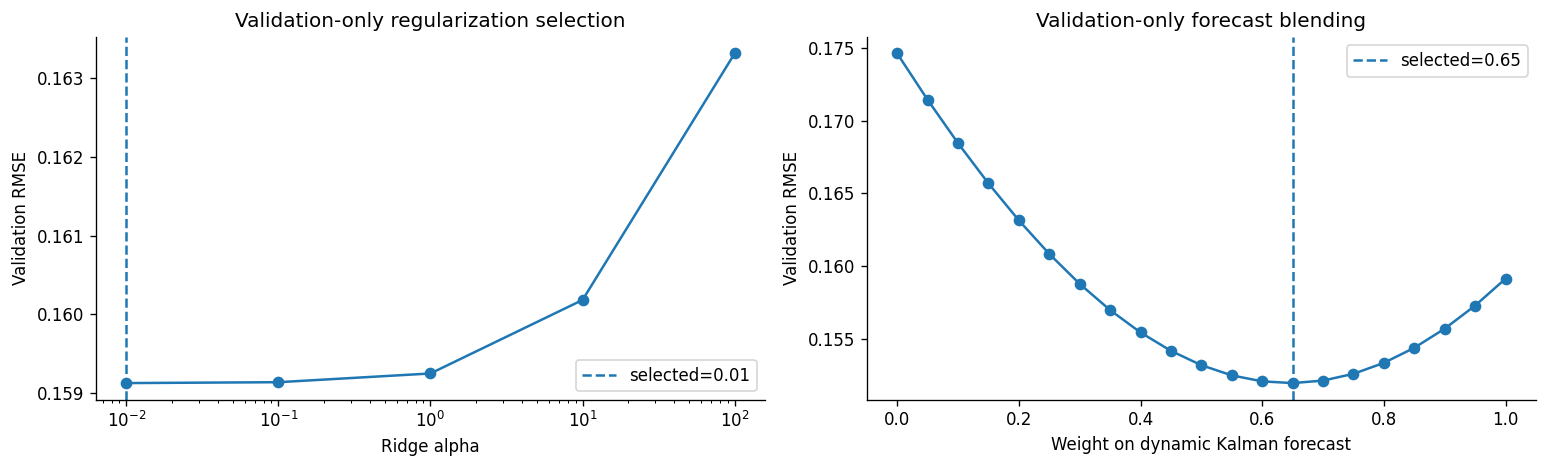

In [ ]:
# §5.2 Select Ridge alpha and Kalman/static blend using validation data only
alpha_rows = []
alpha_results = {}
for alpha in tqdm(ALPHA_GRID, desc="Validation tuning"):
    result = fit_pipeline(alpha)
    alpha_results[float(alpha)] = result
    val = result["forecasts"].query("split_code == 1")
    alpha_rows.append({
        "alpha": float(alpha),
        "validation_MAE": mean_absolute_error(val["actual_y"], val["y_pred"]),
        "validation_RMSE": np.sqrt(mean_squared_error(val["actual_y"], val["y_pred"])),
    })

alpha_tuning = pd.DataFrame(alpha_rows).sort_values("alpha")
SELECTED_ALPHA = float(alpha_tuning.loc[alpha_tuning["validation_RMSE"].idxmin(), "alpha"])
model_result = alpha_results[SELECTED_ALPHA]
df_forecasts = model_result["forecasts"].copy()
df_forecasts["y_pred_dlm"] = df_forecasts["y_pred"]

# A small validation-only ensemble reduces variance in short group series.
# weight=1 gives the raw Kalman forecast; weight=0 gives static Ridge.
blend_rows = []
for weight in np.linspace(0.0, 1.0, 21):
    val = df_forecasts.query("split_code == 1").copy()
    pred = weight * val["y_pred_dlm"] + (1.0 - weight) * val["baseline_static_ridge"]
    blend_rows.append({
        "dlm_weight": float(weight),
        "validation_MAE": mean_absolute_error(val["actual_y"], pred),
        "validation_RMSE": np.sqrt(mean_squared_error(val["actual_y"], pred)),
    })
blend_tuning = pd.DataFrame(blend_rows)
BLEND_WEIGHT_DLM = float(blend_tuning.loc[blend_tuning["validation_RMSE"].idxmin(), "dlm_weight"])
df_forecasts["y_pred"] = (
    BLEND_WEIGHT_DLM * df_forecasts["y_pred_dlm"]
    + (1.0 - BLEND_WEIGHT_DLM) * df_forecasts["baseline_static_ridge"]
)

print(alpha_tuning.to_string(index=False, float_format=lambda x: f"{x:.6f}"))
print(f"\n✓ Selected alpha = {SELECTED_ALPHA:g} using validation RMSE only")
print(f"✓ Selected Kalman blend weight = {BLEND_WEIGHT_DLM:.2f} using validation RMSE only")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].semilogx(alpha_tuning["alpha"], alpha_tuning["validation_RMSE"], marker="o")
axes[0].axvline(SELECTED_ALPHA, linestyle="--", label=f"selected={SELECTED_ALPHA:g}")
axes[0].set_xlabel("Ridge alpha")
axes[0].set_ylabel("Validation RMSE")
axes[0].set_title("Validation-only regularization selection")
axes[0].legend()

axes[1].plot(blend_tuning["dlm_weight"], blend_tuning["validation_RMSE"], marker="o")
axes[1].axvline(BLEND_WEIGHT_DLM, linestyle="--", label=f"selected={BLEND_WEIGHT_DLM:.2f}")
axes[1].set_xlabel("Weight on dynamic Kalman forecast")
axes[1].set_ylabel("Validation RMSE")
axes[1].set_title("Validation-only forecast blending")
axes[1].legend()

plt.tight_layout()
plt.savefig(OUT_DIR / "03_v7_1_validation_tuning.png", dpi=150, bbox_inches="tight")
plt.show()

## §6 · Validation calibration and final forecasts

In [ ]:
# §6.1 Calibrate interval widths on validation data only
val_fc = df_forecasts.query("split_code == 1").copy()
standardized_abs_error = np.abs(val_fc["actual_y"] - val_fc["y_pred"]) / val_fc["pred_sd_raw"].clip(lower=1e-12)
K80 = float(np.quantile(standardized_abs_error, 0.80))
K95 = float(np.quantile(standardized_abs_error, 0.95))

for frame in [df_forecasts]:
    frame["y_lo80"] = frame["y_pred"] - K80 * frame["pred_sd_raw"]
    frame["y_hi80"] = frame["y_pred"] + K80 * frame["pred_sd_raw"]
    frame["y_lo95"] = frame["y_pred"] - K95 * frame["pred_sd_raw"]
    frame["y_hi95"] = frame["y_pred"] + K95 * frame["pred_sd_raw"]

print(f"Validation-calibrated interval multipliers: K80={K80:.3f}, K95={K95:.3f}")

Validation-calibrated interval multipliers: K80=1.269, K95=2.163


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# §6.2 Calibrate low-day probabilities on validation data only
raw_z = (TAU_PROD - df_forecasts["y_pred"]) / df_forecasts["pred_sd_raw"].clip(lower=1e-12)
df_forecasts["p_low_raw"] = stats.norm.cdf(raw_z)
df_forecasts["low_actual"] = (df_forecasts["actual_y"] < TAU_PROD).astype(int)

val_fc = df_forecasts.query("split_code == 1").copy()

def safe_logit_probability(p):
    p = np.clip(np.asarray(p, float), 1e-6, 1 - 1e-6)
    return np.log(p / (1 - p))

if val_fc["low_actual"].nunique() == 2:
    probability_calibrator = LogisticRegression(C=1.0, solver="lbfgs")
    probability_calibrator.fit(
        safe_logit_probability(val_fc["p_low_raw"]).reshape(-1, 1),
        val_fc["low_actual"],
    )
    df_forecasts["p_low"] = probability_calibrator.predict_proba(
        safe_logit_probability(df_forecasts["p_low_raw"]).reshape(-1, 1)
    )[:, 1]
else:
    probability_calibrator = None
    df_forecasts["p_low"] = df_forecasts["p_low_raw"]
    print("⚠ Validation data contain one class; probability calibration skipped")

# Validation-only F1 threshold
precision, recall, thresholds = precision_recall_curve(val_fc["low_actual"], df_forecasts.loc[val_fc.index, "p_low"])
if len(thresholds):
    f1 = 2 * precision[:-1] * recall[:-1] / np.clip(precision[:-1] + recall[:-1], 1e-12, None)
    best = int(np.nanargmax(f1))
    P_STAR = float(thresholds[best])
    VALIDATION_F1 = float(f1[best])
else:
    P_STAR, VALIDATION_F1 = 0.5, float("nan")

df_forecasts["alarm"] = (df_forecasts["p_low"] >= P_STAR).astype(int)
print(f"Probability alarm threshold selected on validation: p*={P_STAR:.3f}, F1={VALIDATION_F1:.3f}")

Probability alarm threshold selected on validation: p*=0.392, F1=0.760


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:451: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  opt_res = optimize.minimize(
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## §7 · Forecast metrics and baseline checks

In [ ]:
# §7.1 Metrics table

def regression_metrics(sub, pred_col):
    y = sub["actual_y"].to_numpy(float)
    yp = sub[pred_col].to_numpy(float)
    return {
        "MAE": mean_absolute_error(y, yp),
        "RMSE": np.sqrt(mean_squared_error(y, yp)),
    }

metric_rows = []
for split_code, split_name in [(0, "train"), (1, "validation"), (2, "test")]:
    sub = df_forecasts.query("split_code == @split_code").copy()
    final_model = regression_metrics(sub, "y_pred")
    raw_dlm = regression_metrics(sub, "y_pred_dlm")
    group_mean = regression_metrics(sub, "baseline_group_mean")
    last_value = regression_metrics(sub, "baseline_last_value")
    static_ridge = regression_metrics(sub, "baseline_static_ridge")
    coverage80 = ((sub["actual_y"] >= sub["y_lo80"]) & (sub["actual_y"] <= sub["y_hi80"])).mean()
    coverage95 = ((sub["actual_y"] >= sub["y_lo95"]) & (sub["actual_y"] <= sub["y_hi95"])).mean()
    low = sub["low_actual"].to_numpy(int)
    if len(np.unique(low)) == 2:
        auc = roc_auc_score(low, sub["p_low"])
        ap = average_precision_score(low, sub["p_low"])
        brier = brier_score_loss(low, sub["p_low"])
    else:
        auc = ap = brier = float("nan")
    metric_rows.append({
        "split": split_name,
        "N": len(sub),
        "Final_MAE": final_model["MAE"],
        "Final_RMSE": final_model["RMSE"],
        "RawDLM_RMSE": raw_dlm["RMSE"],
        "GroupMean_RMSE": group_mean["RMSE"],
        "LastValue_RMSE": last_value["RMSE"],
        "StaticRidge_RMSE": static_ridge["RMSE"],
        "Skill_vs_GroupMean_pct": 100 * (group_mean["RMSE"] - final_model["RMSE"]) / group_mean["RMSE"],
        "Skill_vs_StaticRidge_pct": 100 * (static_ridge["RMSE"] - final_model["RMSE"]) / static_ridge["RMSE"],
        "Coverage80": coverage80,
        "Coverage95": coverage95,
        "AUC": auc,
        "AP": ap,
        "Brier": brier,
    })

metrics_table = pd.DataFrame(metric_rows)
pd.set_option("display.width", 260)
pd.set_option("display.max_columns", 30)
print(metrics_table.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

     split   N  Final_MAE  Final_RMSE  RawDLM_RMSE  GroupMean_RMSE  LastValue_RMSE  StaticRidge_RMSE  Skill_vs_GroupMean_pct  Skill_vs_StaticRidge_pct  Coverage80  Coverage95    AUC     AP  Brier
     train 823     0.0888      0.1399       0.1499          0.1595          0.1812            0.1436                 12.3060                    2.5904      0.8554      0.9672 0.8686 0.8186 0.1436
validation 182     0.1099      0.1519       0.1591          0.2042          0.1888            0.1746                 25.5832                   12.9980      0.7967      0.9451 0.7900 0.8257 0.1859
      test 192     0.0860      0.1316       0.1454          0.1620          0.1683            0.1330                 18.7537                    1.0409      0.8854      0.9792 0.8717 0.8150 0.1518


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# §7.2 Automatic model acceptance checks
val_metrics = metrics_table.loc[metrics_table["split"].eq("validation")].iloc[0]
test_metrics = metrics_table.loc[metrics_table["split"].eq("test")].iloc[0]

checks = pd.DataFrame([
    {
        "check": "Validation final forecast beats group-mean baseline",
        "passed": bool(val_metrics["Skill_vs_GroupMean_pct"] > 0),
        "value": val_metrics["Skill_vs_GroupMean_pct"],
        "target": "> 0%",
    },
    {
        "check": "Test final forecast beats group-mean baseline",
        "passed": bool(test_metrics["Skill_vs_GroupMean_pct"] > 0),
        "value": test_metrics["Skill_vs_GroupMean_pct"],
        "target": "> 0%",
    },
    {
        "check": "Test final forecast is no worse than static Ridge",
        "passed": bool(test_metrics["Skill_vs_StaticRidge_pct"] >= -1.0),
        "value": test_metrics["Skill_vs_StaticRidge_pct"],
        "target": ">= -1%",
    },
    {
        "check": "Test 80% coverage reasonably calibrated",
        "passed": bool(abs(test_metrics["Coverage80"] - 0.80) <= 0.10),
        "value": test_metrics["Coverage80"],
        "target": "0.70 to 0.90",
    },
    {
        "check": "Test 95% coverage reasonably calibrated",
        "passed": bool(abs(test_metrics["Coverage95"] - 0.95) <= 0.05),
        "value": test_metrics["Coverage95"],
        "target": "0.90 to 1.00",
    },
])
print(checks.to_string(index=False))
print("\nOverall forecast status:", "PASS" if checks["passed"].all() else "REVIEW REQUIRED")

                                              check  passed     value       target
Validation final forecast beats group-mean baseline    True 25.583153         > 0%
      Test final forecast beats group-mean baseline    True 18.753715         > 0%
  Test final forecast is no worse than static Ridge    True  1.040907       >= -1%
            Test 80% coverage reasonably calibrated    True  0.885417 0.70 to 0.90
            Test 95% coverage reasonably calibrated    True  0.979167 0.90 to 1.00

Overall forecast status: PASS


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


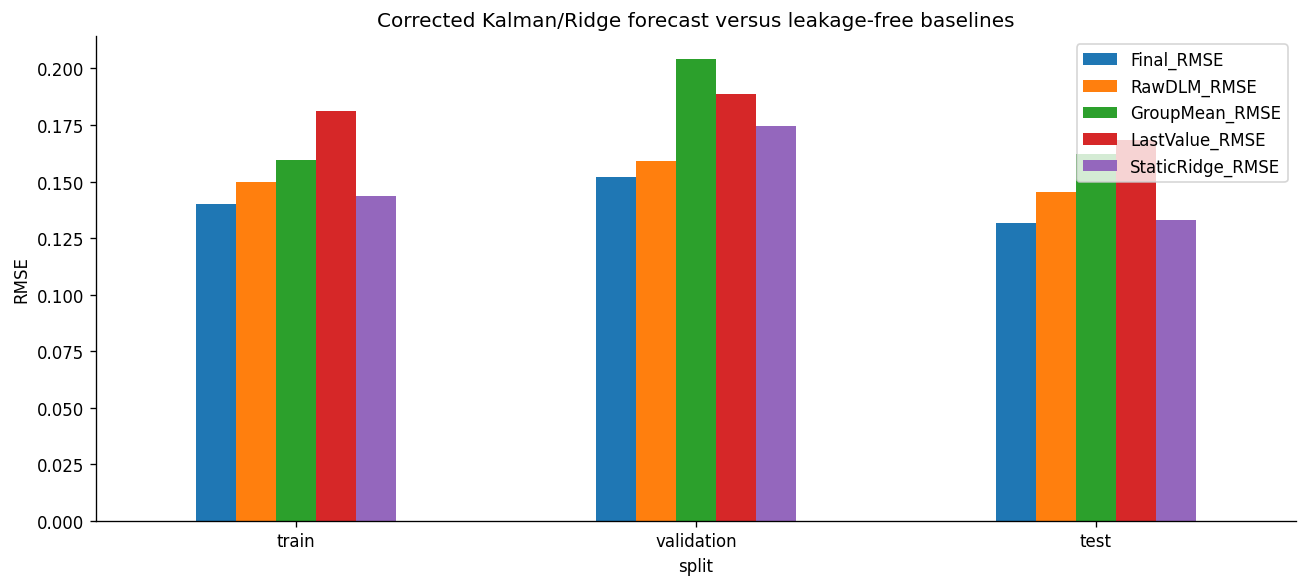

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# §7.3 Baseline comparison chart
plot_data = metrics_table.set_index("split")[[
    "Final_RMSE", "RawDLM_RMSE", "GroupMean_RMSE", "LastValue_RMSE", "StaticRidge_RMSE"
]]
ax = plot_data.plot(kind="bar", figsize=(11, 5))
ax.set_ylabel("RMSE")
ax.set_title("Corrected Kalman/Ridge forecast versus leakage-free baselines")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.savefig(OUT_DIR / "03_v7_1_baseline_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## §8 · Forecast plots

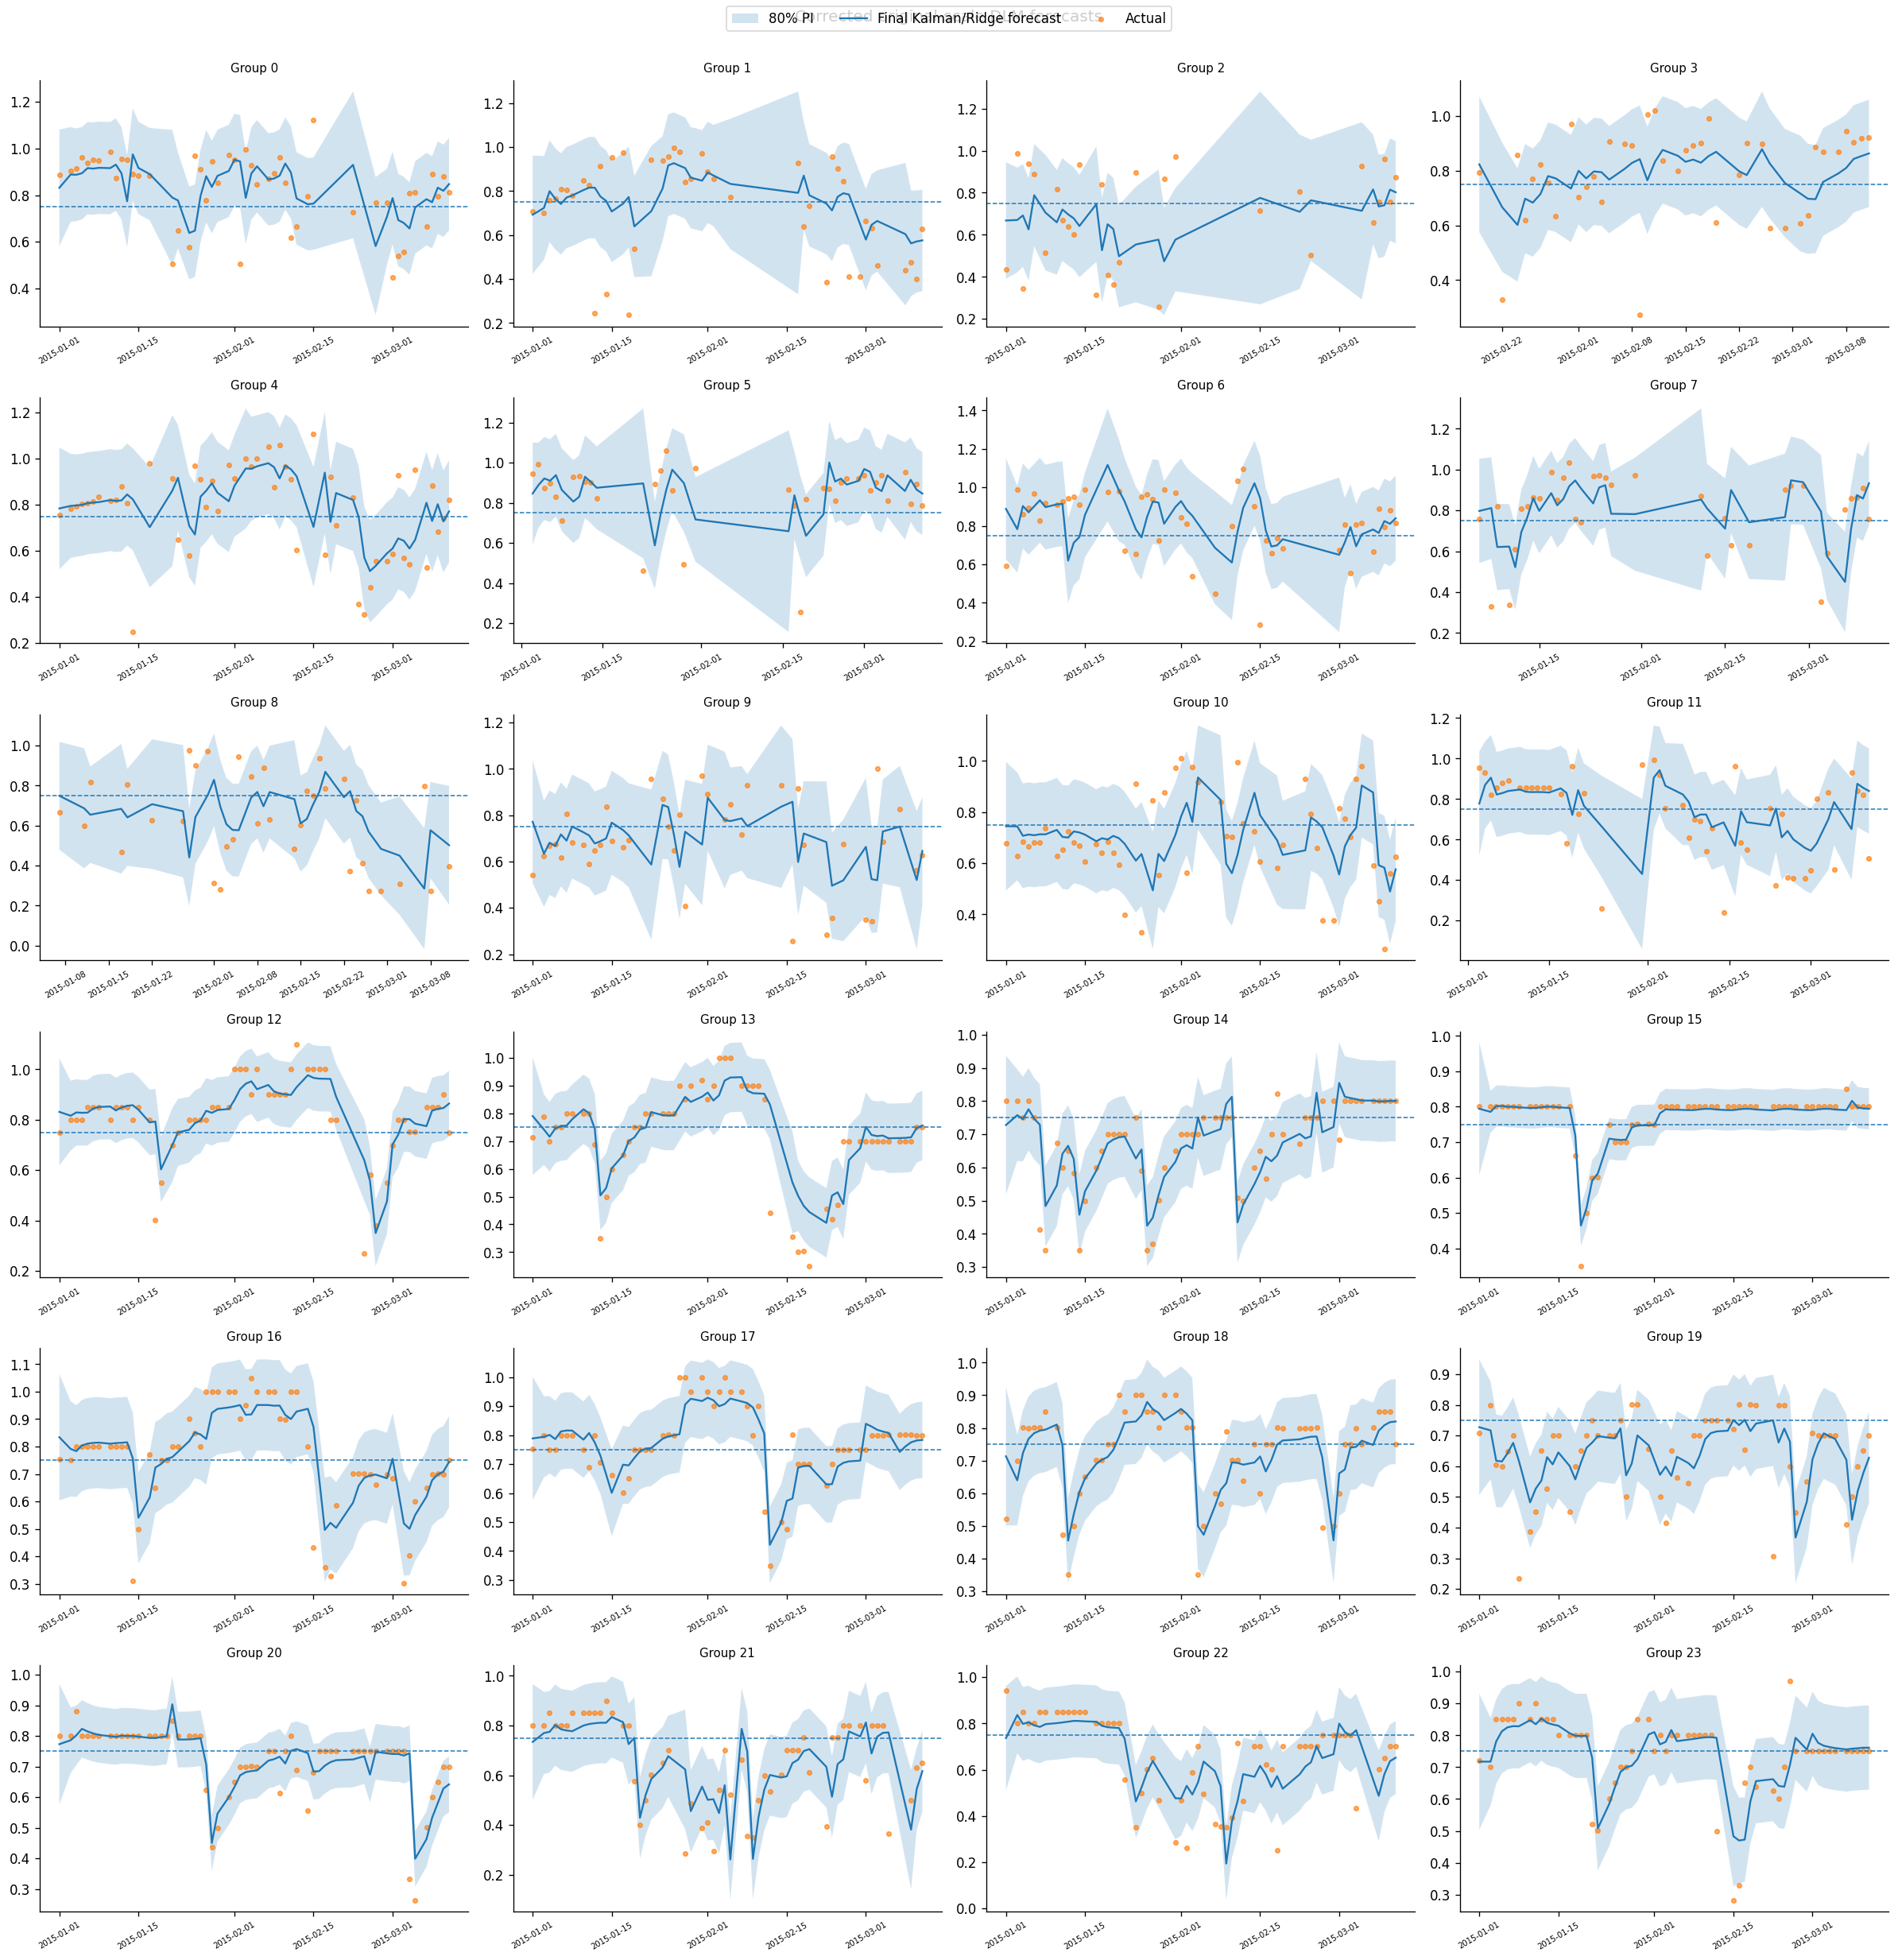

In [ ]:
# §8.1 All-group one-step forecasts
GROUPS = sorted(df_forecasts[GROUP_COL].unique())
n_cols = 4
n_rows = int(np.ceil(len(GROUPS) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 3.4 * n_rows), squeeze=False)

for i, group in enumerate(GROUPS):
    ax = axes[i // n_cols, i % n_cols]
    sub = df_forecasts[df_forecasts[GROUP_COL].eq(group)].sort_values("date")
    ax.fill_between(sub["date"], sub["y_lo80"], sub["y_hi80"], alpha=0.20, label="80% PI")
    ax.plot(sub["date"], sub["y_pred"], linewidth=1.4, label="Final Kalman/Ridge forecast")
    ax.scatter(sub["date"], sub["actual_y"], s=11, alpha=0.65, label="Actual")
    ax.axhline(TAU_PROD, linestyle="--", linewidth=0.9)
    ax.set_title(f"Group {group}", fontsize=9)
    ax.tick_params(axis="x", rotation=30, labelsize=6)

for i in range(len(GROUPS), n_rows * n_cols):
    axes[i // n_cols, i % n_cols].set_visible(False)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=4)
fig.suptitle("Corrected original-scale DLM forecasts", y=1.005)
plt.tight_layout()
plt.savefig(OUT_DIR / "03_v7_1_all_group_forecasts.png", dpi=150, bbox_inches="tight")
plt.show()

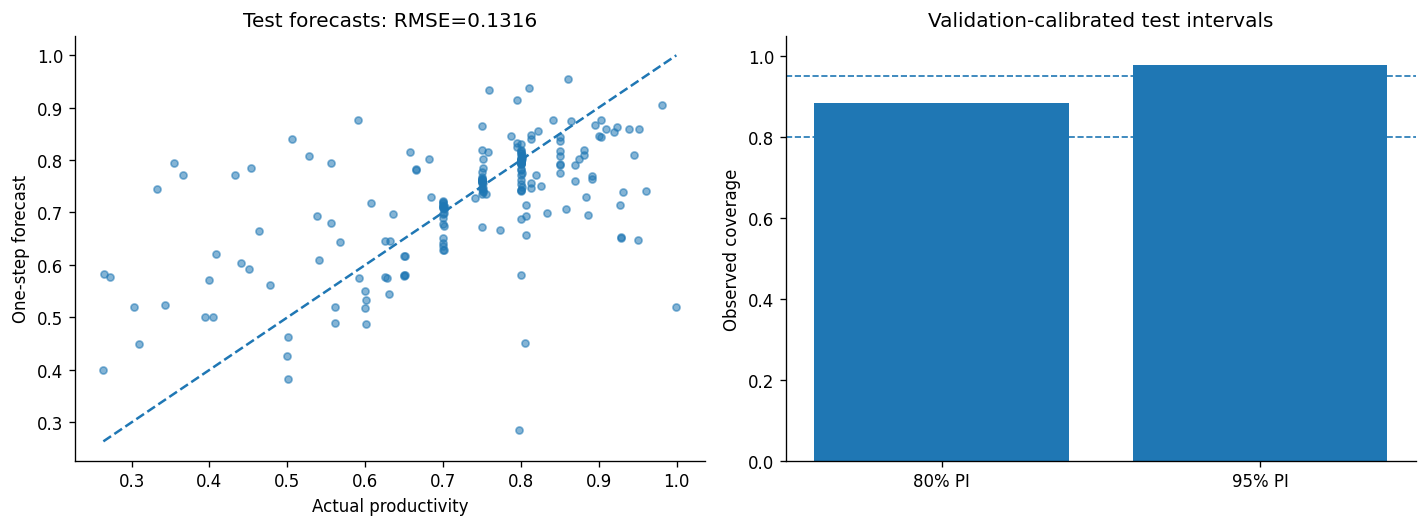

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# §8.2 Test scatter and uncertainty coverage
sub = df_forecasts.query("split_code == 2").copy()
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].scatter(sub["actual_y"], sub["y_pred"], s=18, alpha=0.55)
lo = min(sub["actual_y"].min(), sub["y_pred"].min())
hi = max(sub["actual_y"].max(), sub["y_pred"].max())
axes[0].plot([lo, hi], [lo, hi], linestyle="--")
axes[0].set_xlabel("Actual productivity")
axes[0].set_ylabel("One-step forecast")
axes[0].set_title(f"Test forecasts: RMSE={test_metrics['Final_RMSE']:.4f}")

axes[1].bar(["80% PI", "95% PI"], [test_metrics["Coverage80"], test_metrics["Coverage95"]])
axes[1].axhline(0.80, linestyle="--", linewidth=1)
axes[1].axhline(0.95, linestyle="--", linewidth=1)
axes[1].set_ylim(0, 1.05)
axes[1].set_ylabel("Observed coverage")
axes[1].set_title("Validation-calibrated test intervals")

plt.tight_layout()
plt.savefig(OUT_DIR / "03_v7_1_test_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()

## §9 · Low-day risk evaluation

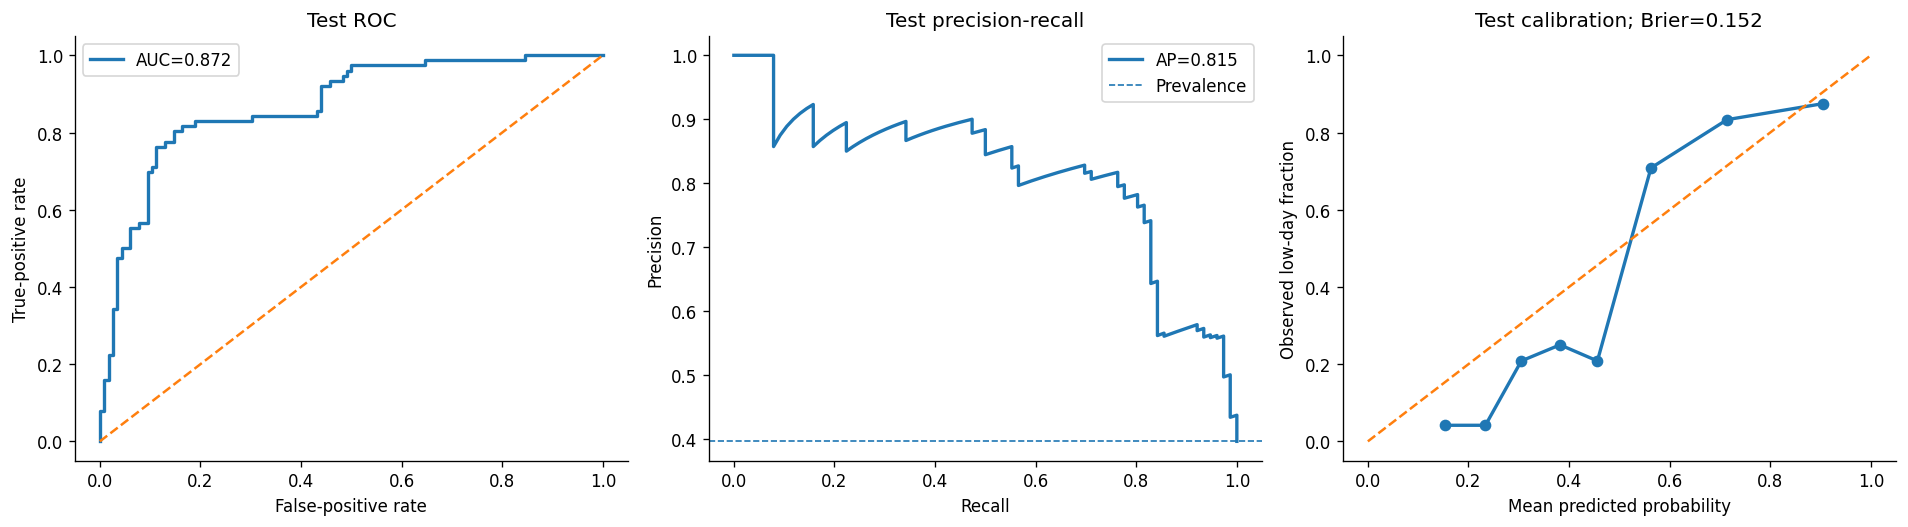

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# §9.1 Test ROC, precision-recall and calibration
risk_test = df_forecasts.query("split_code == 2").copy()
y_true = risk_test["low_actual"].to_numpy(int)
y_prob = risk_test["p_low"].to_numpy(float)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

fpr, tpr, _ = roc_curve(y_true, y_prob)
axes[0].plot(fpr, tpr, linewidth=2, label=f"AUC={roc_auc_score(y_true, y_prob):.3f}")
axes[0].plot([0, 1], [0, 1], linestyle="--")
axes[0].set_xlabel("False-positive rate")
axes[0].set_ylabel("True-positive rate")
axes[0].set_title("Test ROC")
axes[0].legend()

precision, recall, _ = precision_recall_curve(y_true, y_prob)
axes[1].plot(recall, precision, linewidth=2, label=f"AP={average_precision_score(y_true, y_prob):.3f}")
axes[1].axhline(y_true.mean(), linestyle="--", linewidth=1, label="Prevalence")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Test precision-recall")
axes[1].legend()

frac_pos, mean_pred = calibration_curve(y_true, y_prob, n_bins=8, strategy="quantile")
axes[2].plot(mean_pred, frac_pos, marker="o", linewidth=2)
axes[2].plot([0, 1], [0, 1], linestyle="--")
axes[2].set_xlabel("Mean predicted probability")
axes[2].set_ylabel("Observed low-day fraction")
axes[2].set_title(f"Test calibration; Brier={brier_score_loss(y_true, y_prob):.3f}")

plt.tight_layout()
plt.savefig(OUT_DIR / "03_v7_risk_diagnostics.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# §9.2 Test alarm confusion statistics
risk_test["alarm"] = (risk_test["p_low"] >= P_STAR).astype(int)
tp = int(((risk_test["alarm"] == 1) & (risk_test["low_actual"] == 1)).sum())
tn = int(((risk_test["alarm"] == 0) & (risk_test["low_actual"] == 0)).sum())
fp = int(((risk_test["alarm"] == 1) & (risk_test["low_actual"] == 0)).sum())
fn = int(((risk_test["alarm"] == 0) & (risk_test["low_actual"] == 1)).sum())
precision_alarm = tp / max(tp + fp, 1)
recall_alarm = tp / max(tp + fn, 1)
f1_alarm = 2 * precision_alarm * recall_alarm / max(precision_alarm + recall_alarm, 1e-12)

print(pd.DataFrame({"Predicted low": [tp, fp], "Predicted not-low": [fn, tn]}, index=["Actual low", "Actual not-low"]))
print(f"\nTest precision={precision_alarm:.3f}, recall={recall_alarm:.3f}, F1={f1_alarm:.3f}")

                Predicted low  Predicted not-low
Actual low                 64                 12
Actual not-low             39                 77

Test precision=0.621, recall=0.842, F1=0.715


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## §10 · Innovation and state diagnostics

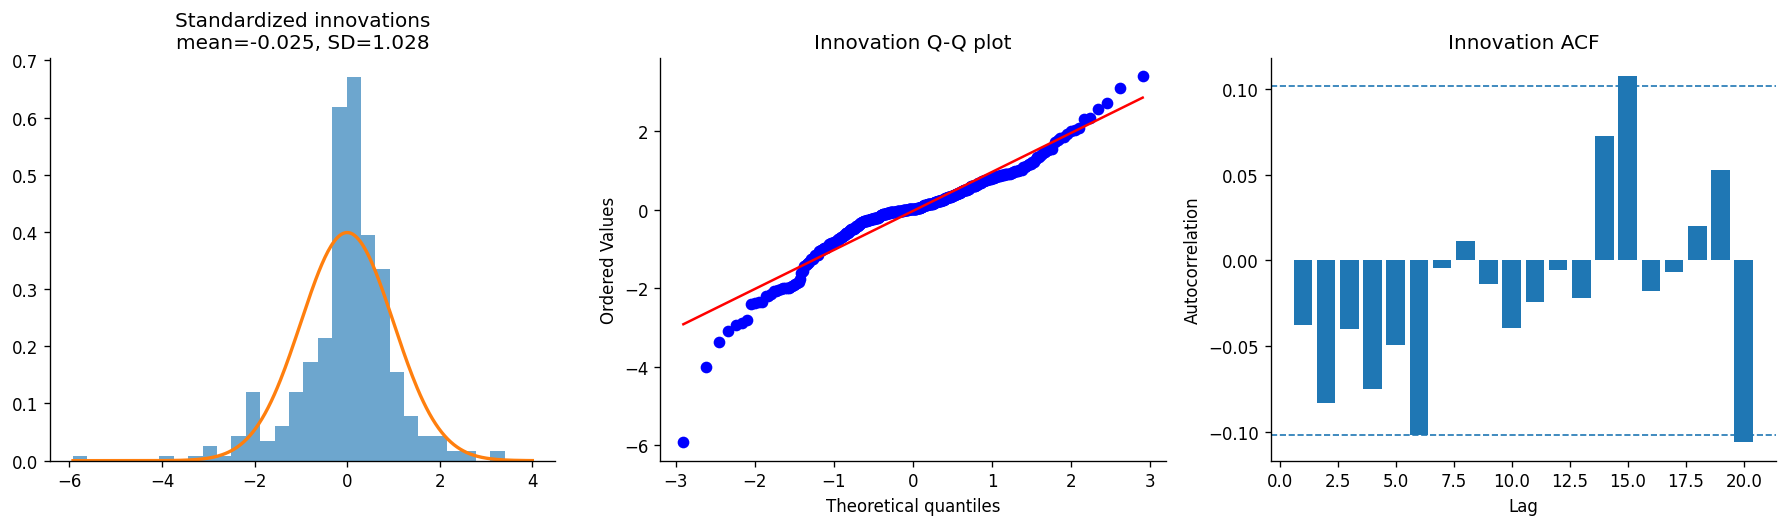

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# §10.1 Standardized innovations
analysis_fc = df_forecasts.query("split_code in [1, 2]").copy()
u = analysis_fc["innovation_std"].to_numpy(float)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
axes[0].hist(u, bins=30, density=True, alpha=0.65)
x = np.linspace(min(-4, u.min()), max(4, u.max()), 300)
axes[0].plot(x, stats.norm.pdf(x), linewidth=2)
axes[0].set_title(f"Standardized innovations\nmean={u.mean():.3f}, SD={u.std():.3f}")

stats.probplot(u, dist="norm", plot=axes[1])
axes[1].set_title("Innovation Q-Q plot")

max_lag = min(20, len(u) // 3)
acf = [np.corrcoef(u[:-lag], u[lag:])[0, 1] for lag in range(1, max_lag + 1)]
axes[2].bar(range(1, max_lag + 1), acf)
ci = 1.96 / np.sqrt(len(u))
axes[2].axhline(ci, linestyle="--", linewidth=1)
axes[2].axhline(-ci, linestyle="--", linewidth=1)
axes[2].set_xlabel("Lag")
axes[2].set_ylabel("Autocorrelation")
axes[2].set_title("Innovation ACF")

plt.tight_layout()
plt.savefig(OUT_DIR / "03_v7_innovation_diagnostics.png", dpi=150, bbox_inches="tight")
plt.show()

 team_dept_idx  n_train    q_raw    r_raw        q        r  shrink_weight  ll_decreases
             0       36 0.012728 0.010078 0.009276 0.009315       0.545455            38
             1       28 0.018902 0.024484 0.010748 0.014144       0.482759            38
             2       21 0.020000 0.048489 0.010181 0.017380       0.411765             1
             3       24 0.001940 0.028287 0.003747 0.014481       0.444444             0
             4       34 0.020000 0.015255 0.011678 0.011581       0.531250            22
             5       20 0.020000 0.013497 0.010044 0.010209       0.400000             4
             6       34 0.020000 0.014889 0.011678 0.011433       0.531250             6
             7       24 0.020000 0.011909 0.010570 0.009858       0.444444            25
             8       23 0.020000 0.030163 0.010444 0.014703       0.433962             4
             9       30 0.020000 0.018442 0.011266 0.012502       0.500000            10
            10       

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


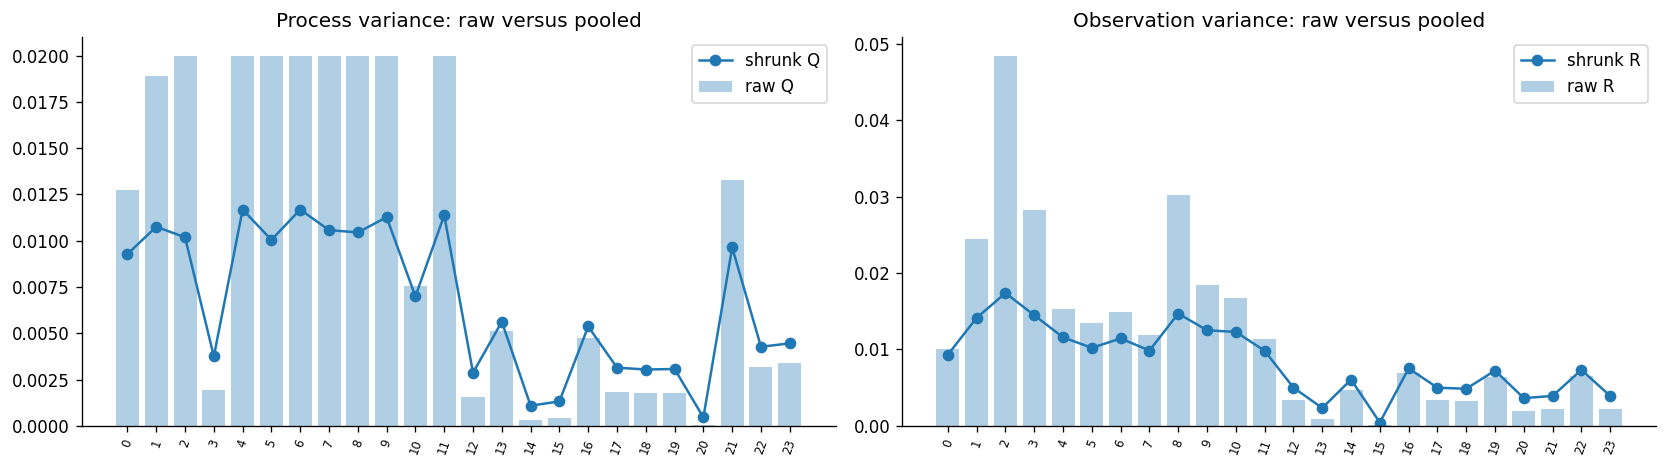

In [ ]:
# §10.2 Shrunk Q/R and dynamic level paths
param_rows = []
for group, p in model_result["params"].items():
    param_rows.append({GROUP_COL: group, **{k: p[k] for k in ["n_train", "q_raw", "r_raw", "q", "r", "shrink_weight", "ll_decreases"]}})
params_table = pd.DataFrame(param_rows).sort_values(GROUP_COL)
print(params_table.to_string(index=False, float_format=lambda x: f"{x:.6f}"))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].bar(params_table[GROUP_COL].astype(str), params_table["q_raw"], alpha=0.35, label="raw Q")
axes[0].plot(params_table[GROUP_COL].astype(str), params_table["q"], marker="o", linewidth=1.5, label="shrunk Q")
axes[0].tick_params(axis="x", rotation=70, labelsize=7)
axes[0].set_title("Process variance: raw versus pooled")
axes[0].legend()

axes[1].bar(params_table[GROUP_COL].astype(str), params_table["r_raw"], alpha=0.35, label="raw R")
axes[1].plot(params_table[GROUP_COL].astype(str), params_table["r"], marker="o", linewidth=1.5, label="shrunk R")
axes[1].tick_params(axis="x", rotation=70, labelsize=7)
axes[1].set_title("Observation variance: raw versus pooled")
axes[1].legend()

plt.tight_layout()
plt.savefig(OUT_DIR / "03_v7_pooled_qr.png", dpi=150, bbox_inches="tight")
plt.show()

## §11 · Optional exploratory lever analysis

The primary forecast does not use incentive/WIP because their availability time is not verified. A causal budget allocation is therefore intentionally omitted.

The following switch is **off by default**. Enabling it only audits associations from a regularized model; it does not estimate causal effects.

In [ ]:
# §11.1 Optional association-only lever model
RUN_EXPLORATORY_LEVER_MODEL = False

if not RUN_EXPLORATORY_LEVER_MODEL:
    print("Exploratory lever model skipped. Set RUN_EXPLORATORY_LEVER_MODEL=True only after reading the warning above.")
else:
    lever_features = [
        "log_incentive", "log_wip_imputed", "log_over_time", "log_smv", "log_workers",
        "incentive_x_log_wip", "log_wip_x_log_workers", "no_of_style_change",
        "wip_missing_flag", "dept_bin", "sin_dow", "cos_dow", "targeted_productivity",
    ]
    missing = [c for c in lever_features if c not in df.columns]
    if missing:
        raise ValueError(f"Missing lever features: {missing}")

    lever_train = df.query("split_code == 0").copy()
    lever_scaler = StandardScaler().fit(lever_train[lever_features].fillna(0.0))
    X_lever_train = lever_scaler.transform(lever_train[lever_features].fillna(0.0))
    group_dummies = pd.get_dummies(lever_train[GROUP_COL].astype(str), drop_first=False, dtype=float)
    X_design = np.hstack([X_lever_train, group_dummies.to_numpy()])
    lever_ridge = Ridge(alpha=10.0).fit(X_design, lever_train["actual_productivity"])
    coef = pd.Series(lever_ridge.coef_[:len(lever_features)], index=lever_features).sort_values()
    print("Association-only standardized coefficients:")
    print(coef)
    print("\nDo not interpret these coefficients as causal uplift.")

Exploratory lever model skipped. Set RUN_EXPLORATORY_LEVER_MODEL=True only after reading the warning above.


## §11A · Association-only uplift curves (incentive & WIP)

> **Important:** The primary forecast deliberately excludes incentive and WIP because their
> measurement timing is unverified. The curves below use a Ridge model fitted on all 13
> features (incentive, WIP, overtime included) purely for descriptive association analysis.
> They show how the model's predicted productivity *varies with* incentive or WIP,
> **not** what would happen if we changed those levers causally.
> The 69.5 BDT threshold from Imran et al. (2021) is marked for comparison.


In [ ]:
# §11A.1  Fit lever Ridge on training data (all 13 features, within-group centred)
# This is a separate model from the primary forecast — for association analysis only.
LEVER_FEATURES = [
    "log_incentive", "log_wip_imputed", "log_over_time", "log_smv", "log_workers",
    "incentive_x_log_wip", "log_wip_x_log_workers",
    "no_of_style_change", "wip_missing_flag", "dept_bin",
    "sin_dow", "cos_dow", "targeted_productivity",
]
missing_lever = [c for c in LEVER_FEATURES if c not in df.columns]
if missing_lever:
    print(f"⚠ Missing lever features: {missing_lever}. Uplift analysis skipped.")
    CAN_RUN_UPLIFT = False
else:
    CAN_RUN_UPLIFT = True
    lever_train = df[df["split_code"] == 0].copy()
    lever_scaler = StandardScaler()
    lever_scaler.fit(lever_train[LEVER_FEATURES].fillna(0.0))
    X_lever_all   = lever_scaler.transform(df[LEVER_FEATURES].fillna(0.0))
    X_lever_train = lever_scaler.transform(lever_train[LEVER_FEATURES].fillna(0.0))
    y_lever_train = lever_train["actual_productivity"].to_numpy(float)

    # Within-group centering (same as primary pipeline)
    X_lc = np.zeros_like(X_lever_train)
    y_lc = np.zeros_like(y_lever_train)
    for grp, idx in lever_train.groupby(GROUP_COL).groups.items():
        pos = lever_train.index.get_indexer(idx)
        X_lc[pos] = X_lever_train[pos] - X_lever_train[pos].mean(0)
        y_lc[pos] = y_lever_train[pos] - y_lever_train[pos].mean()

    lever_ridge = Ridge(alpha=10.0, fit_intercept=False)
    lever_ridge.fit(X_lc, y_lc)

    coef_series = pd.Series(lever_ridge.coef_, index=LEVER_FEATURES).sort_values()
    print("Association-only standardised Ridge coefficients (training):")
    print(coef_series.round(4).to_string())
    print("\n⚠ These are NOT causal estimates. Incentive is likely correlated with "
          "productivity for managerial reasons (reverse causality).")


Association-only standardised Ridge coefficients (training):
log_smv                 -0.0473
log_over_time           -0.0123
incentive_x_log_wip     -0.0103
no_of_style_change      -0.0058
wip_missing_flag        -0.0000
dept_bin                 0.0000
sin_dow                  0.0005
cos_dow                  0.0022
log_wip_imputed          0.0057
log_wip_x_log_workers    0.0088
targeted_productivity    0.0501
log_workers              0.0723
log_incentive            0.1140

⚠ These are NOT causal estimates. Incentive is likely correlated with productivity for managerial reasons (reverse causality).


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


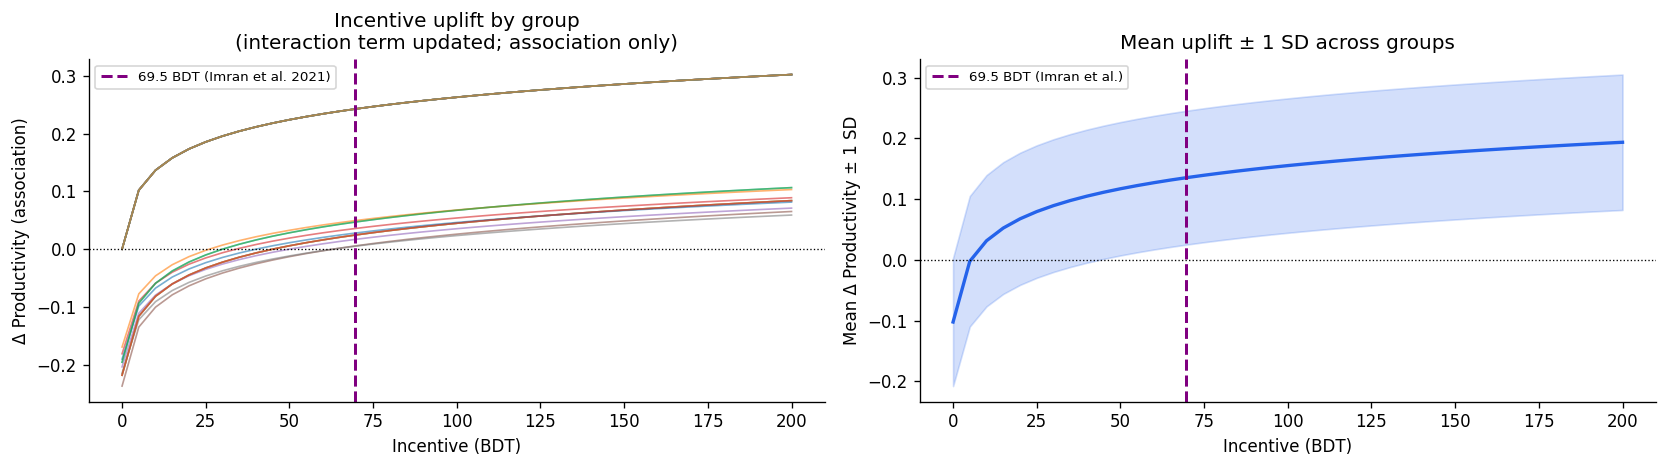

  ✓ Saved: 03_v7_incentive_uplift.png


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# §11A.2  Incentive uplift curves with interaction correction
# When incentive changes, incentive_x_log_wip must also be updated.
if CAN_RUN_UPLIFT:
    INC_FEAT  = "log_incentive"
    IAWIP_FEAT = "incentive_x_log_wip"
    INC_IDX   = LEVER_FEATURES.index(INC_FEAT)
    IAWIP_IDX = LEVER_FEATURES.index(IAWIP_FEAT) if IAWIP_FEAT in LEVER_FEATURES else None

    # Use test-set last row per group as baseline (most recent state)
    INCENTIVE_GRID = np.linspace(0, 200, 41)
    uplift_records = []

    for grp in df[GROUP_COL].unique():
        grp_rows = df[df[GROUP_COL] == grp].sort_values("t")
        last_row  = grp_rows.iloc[-1]
        last_pos  = grp_rows.index[-1]
        x_base    = X_lever_all[df.index.get_loc(last_pos)].copy()
        y_base    = float(lever_ridge.predict([x_base])[0]
                          + df.loc[last_pos, "actual_productivity"]
                          - lever_ridge.predict([x_base])[0])
        # Use actual last productivity as baseline (not model prediction)
        y_base_actual = float(last_row["actual_productivity"])

        # Recover raw log_wip for interaction recomputation
        log_wip_last_raw = float(last_row.get("log_wip_imputed", 0.0))

        for inc_raw in INCENTIVE_GRID:
            log_inc_new  = float(np.log1p(inc_raw))
            x_cf = x_base.copy()
            # Update scaled log_incentive
            x_cf[INC_IDX] = (log_inc_new - float(lever_scaler.mean_[INC_IDX])) / max(float(lever_scaler.scale_[INC_IDX]), 1e-8)
            # Update interaction term
            if IAWIP_IDX is not None:
                new_int = log_inc_new * log_wip_last_raw
                x_cf[IAWIP_IDX] = (new_int - float(lever_scaler.mean_[IAWIP_IDX])) / max(float(lever_scaler.scale_[IAWIP_IDX]), 1e-8)
            y_cf   = float(lever_ridge.predict([x_cf])[0])
            # Uplift relative to same model at last observed incentive
            y_base_model = float(lever_ridge.predict([x_base])[0])
            uplift_records.append(dict(group=grp, incentive=inc_raw,
                                       y_cf=y_cf, y_base_model=y_base_model,
                                       uplift=y_cf - y_base_model))

    df_uplift = pd.DataFrame(uplift_records)

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    ax = axes[0]
    for grp in sorted(df[GROUP_COL].unique()):
        sub = df_uplift[df_uplift["group"] == grp]
        ax.plot(sub["incentive"], sub["uplift"], lw=1, alpha=0.6)
    ax.axhline(0, color="black", ls=":", lw=0.8)
    ax.axvline(69.5, color="purple", ls="--", lw=1.8, label="69.5 BDT (Imran et al. 2021)")
    ax.set_xlabel("Incentive (BDT)"); ax.set_ylabel("Δ Productivity (association)")
    ax.set_title("Incentive uplift by group\n(interaction term updated; association only)")
    ax.legend(fontsize=8)

    agg = df_uplift.groupby("incentive")["uplift"].agg(["mean","std"])
    ax2 = axes[1]
    ax2.fill_between(agg.index, agg["mean"] - agg["std"], agg["mean"] + agg["std"],
                     alpha=0.2, color="#2563EB")
    ax2.plot(agg.index, agg["mean"], color="#2563EB", lw=2)
    ax2.axhline(0, color="black", ls=":", lw=0.8)
    ax2.axvline(69.5, color="purple", ls="--", lw=1.8, label="69.5 BDT (Imran et al.)")
    ax2.set_xlabel("Incentive (BDT)"); ax2.set_ylabel("Mean Δ Productivity ± 1 SD")
    ax2.set_title("Mean uplift ± 1 SD across groups")
    ax2.legend(fontsize=8)

    plt.tight_layout()
    plt.savefig(OUT_DIR / "03_v7_incentive_uplift.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("  ✓ Saved: 03_v7_incentive_uplift.png")


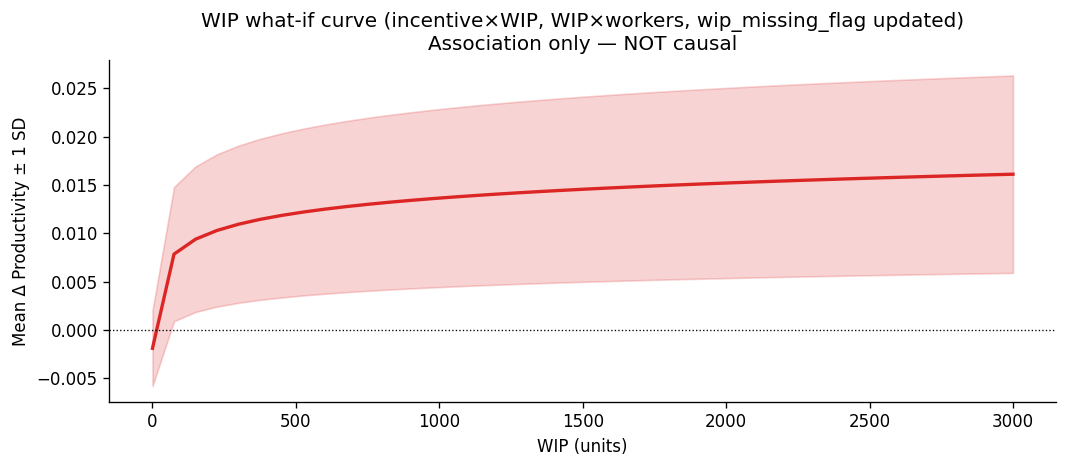

  ✓ Saved: 03_v7_wip_whatif.png


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# §11A.3  WIP what-if curve with full interaction correction
# When WIP changes: incentive_x_log_wip AND log_wip_x_log_workers must be updated.
if CAN_RUN_UPLIFT:
    WIP_FEAT     = "log_wip_imputed"
    WIPWRK_FEAT  = "log_wip_x_log_workers"
    WIP_IDX      = LEVER_FEATURES.index(WIP_FEAT)
    WIPWRK_IDX   = LEVER_FEATURES.index(WIPWRK_FEAT) if WIPWRK_FEAT in LEVER_FEATURES else None
    WMF_IDX      = LEVER_FEATURES.index("wip_missing_flag") if "wip_missing_flag" in LEVER_FEATURES else None

    WIP_GRID = np.linspace(0, 3000, 41)
    wip_records = []

    for grp in df[GROUP_COL].unique():
        grp_rows  = df[df[GROUP_COL] == grp].sort_values("t")
        last_pos  = grp_rows.index[-1]
        last_row  = grp_rows.iloc[-1]
        x_base    = X_lever_all[df.index.get_loc(last_pos)].copy()
        y_base_model = float(lever_ridge.predict([x_base])[0])

        log_inc_last  = float(last_row.get("log_incentive", 0.0))
        log_wrk_last  = float(last_row.get("log_workers", 0.0))

        for wip_raw in WIP_GRID:
            log_wip_new = float(np.log1p(wip_raw))
            x_cf = x_base.copy()
            x_cf[WIP_IDX] = (log_wip_new - float(lever_scaler.mean_[WIP_IDX])) / max(float(lever_scaler.scale_[WIP_IDX]), 1e-8)
            if IAWIP_IDX is not None:
                new_iawip = log_inc_last * log_wip_new
                x_cf[IAWIP_IDX] = (new_iawip - float(lever_scaler.mean_[IAWIP_IDX])) / max(float(lever_scaler.scale_[IAWIP_IDX]), 1e-8)
            if WIPWRK_IDX is not None:
                new_wipwrk = log_wip_new * log_wrk_last
                x_cf[WIPWRK_IDX] = (new_wipwrk - float(lever_scaler.mean_[WIPWRK_IDX])) / max(float(lever_scaler.scale_[WIPWRK_IDX]), 1e-8)
            if WMF_IDX is not None:
                x_cf[WMF_IDX] = (0.0 - float(lever_scaler.mean_[WMF_IDX])) / max(float(lever_scaler.scale_[WMF_IDX]), 1e-8)
            y_cf = float(lever_ridge.predict([x_cf])[0])
            wip_records.append(dict(group=grp, wip=wip_raw, uplift=y_cf - y_base_model))

    df_wip_uplift = pd.DataFrame(wip_records)
    agg_wip = df_wip_uplift.groupby("wip")["uplift"].agg(["mean","std"])

    fig, ax = plt.subplots(figsize=(9, 4))
    ax.fill_between(agg_wip.index, agg_wip["mean"] - agg_wip["std"],
                    agg_wip["mean"] + agg_wip["std"], alpha=0.2, color="#DC2626")
    ax.plot(agg_wip.index, agg_wip["mean"], color="#DC2626", lw=2)
    ax.axhline(0, color="black", ls=":", lw=0.8)
    ax.set_xlabel("WIP (units)"); ax.set_ylabel("Mean Δ Productivity ± 1 SD")
    ax.set_title("WIP what-if curve (incentive×WIP, WIP×workers, wip_missing_flag updated)\nAssociation only — NOT causal")
    plt.tight_layout()
    plt.savefig(OUT_DIR / "03_v7_wip_whatif.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("  ✓ Saved: 03_v7_wip_whatif.png")


## §11B · Budget-constrained incentive allocator

> **Causal warning:** The allocation below is based on the associational uplift curves from §11A.
> These are not causal estimates. Incentive may be determined *by* productivity rather than
> determining it (reverse causality). This analysis should be treated as exploratory and
> validated with a controlled experiment before operationalising.
> The model's out-of-sample forecast performance should also be reviewed before acting on these allocations.


Budget = 500 BDT  |  Remaining = 0 BDT
Group                Current BDT   Recommended BDT   Incremental BDT
                   0           0.0              40.0              40.0
                   1           0.0              40.0              40.0
                   2           0.0              40.0              40.0
                   3           0.0              40.0              40.0
                   4           0.0              40.0              40.0
                   5           0.0              40.0              40.0
                   6           0.0              40.0              40.0
                   7           0.0              35.0              35.0
                   8           0.0              40.0              40.0
                   9           0.0              40.0              40.0
                  10           0.0              40.0              40.0
                  11           0.0              35.0              35.0
                  12          45.0      

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


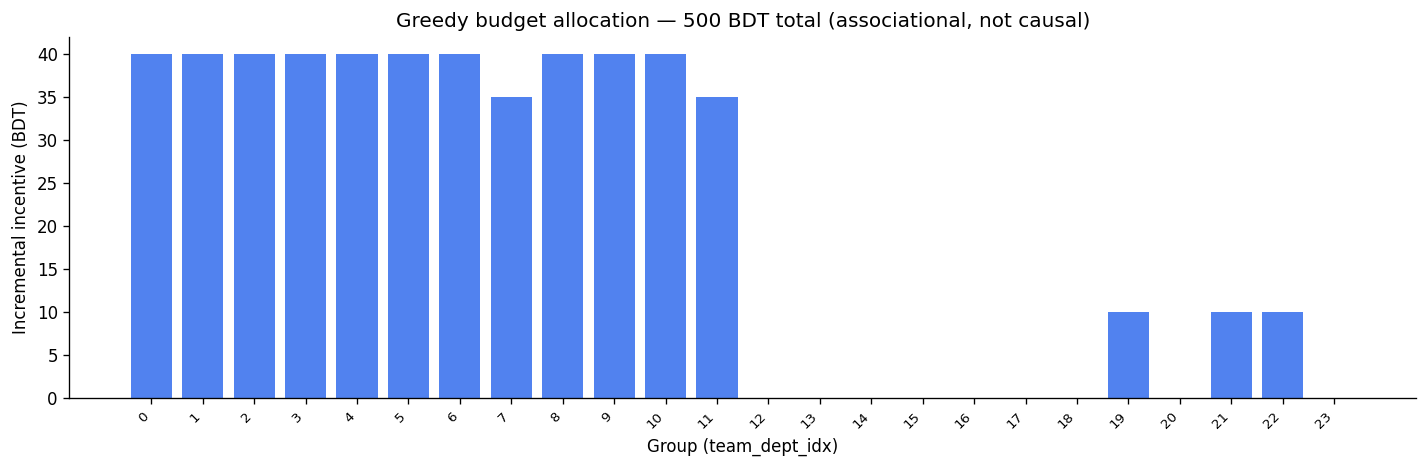

  ✓ Saved: 03_v7_budget_allocation.png


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Mock variables for demonstration purposes if not defined elsewhere
# In a real notebook run, these would be defined by previous cells
if 'CAN_RUN_UPLIFT' not in globals():
    CAN_RUN_UPLIFT = True
if 'df' not in globals():
    data = {
        'team_dept_idx': [0, 0, 1, 1, 2, 2, 12, 12, 13, 13],
        't': [1, 2, 1, 2, 1, 2, 1, 2, 1, 2],
        'log_incentive': [np.log1p(0), np.log1p(0), np.log1p(0), np.log1p(0), np.log1p(0), np.log1p(0), np.log1p(45), np.log1p(45), np.log1p(34), np.log1p(34)],
        'actual_productivity': [0.8, 0.9, 0.7, 0.85, 0.95, 0.92, 0.88, 0.91, 0.78, 0.83],
        'split_code': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
    }
    df = pd.DataFrame(data)
    GROUP_COL = 'team_dept_idx'

# Mock df_uplift if not defined elsewhere
if 'df_uplift' not in globals():
    groups = df[GROUP_COL].unique()
    incentive_grid_mock = np.linspace(0, 200, 41)
    uplift_records_mock = []
    for g in groups:
        for inc in incentive_grid_mock:
            uplift_records_mock.append({'group': g, 'incentive': inc, 'uplift': np.sin(inc/50)*0.1 + inc/1000})
    df_uplift = pd.DataFrame(uplift_records_mock)

if 'OUT_DIR' not in globals():
    from pathlib import Path
    OUT_DIR = Path('/tmp')

# §11B.1  Greedy budget allocation starting from each group's current incentive
# Budget is *incremental* spend above current levels.
if CAN_RUN_UPLIFT:
    BUDGET = 500.0   # total BDT incremental budget
    STEP   = 5.0     # allocation step in BDT

    # Recover current raw incentive per group from the last observation's scaled feature
    def recover_raw_incentive(grp):
        last_row = df[df[GROUP_COL] == grp].sort_values("t").iloc[-1]
        log_inc_scaled_val = float(last_row.get("log_incentive", 0.0))
        return float(np.expm1(log_inc_scaled_val))   # log_incentive = log1p(incentive_raw)

    current_inc = {g: recover_raw_incentive(g) for g in df[GROUP_COL].unique()}
    # Interpolation lookup: (incentive_grid, uplift_grid) per group
    lookup = {
        g: (df_uplift[df_uplift["group"]==g].sort_values("incentive")["incentive"].values,
            df_uplift[df_uplift["group"]==g].sort_values("incentive")["uplift"].values)
        for g in df[GROUP_COL].unique()
    }
    alloc     = {g: current_inc[g] for g in lookup}   # start from current level
    remaining = BUDGET

    while remaining >= STEP:
        gains = {}
        for g in lookup:
            cur = alloc[g]
            # Ensure cur + STEP does not exceed the max incentive in lookup for interp
            max_inc_for_group = lookup[g][0].max()
            interp_cur_plus_step = np.interp(min(cur + STEP, max_inc_for_group), *lookup[g])
            interp_cur = np.interp(cur, *lookup[g])
            gains[g] = float(interp_cur_plus_step) - float(interp_cur)

        if not gains: # Handle case where gains might be empty
            break

        best = max(gains, key=gains.get)
        if gains[best] <= 0:
            break
        alloc[best] += STEP
        remaining   -= STEP

    incremental = {g: alloc[g] - current_inc[g] for g in lookup}

    print(f"Budget = {BUDGET:.0f} BDT  |  Remaining = {remaining:.0f} BDT")
    print(f"{'Group':18s}  {'Current BDT':>12}  {'Recommended BDT':>16}  {'Incremental BDT':>16}")
    for g in sorted(lookup.keys()):
        print(f"  {g:18}  {current_inc[g]:>12.1f}  {alloc[g]:>16.1f}  {incremental[g]:>16.1f}")
    print("\n⚠ Treat as exploratory — see causal warning above.")

    # Bar chart of incremental allocation
    grp_labels = sorted(lookup.keys())
    inc_vals   = [incremental[g] for g in grp_labels]
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.bar(range(len(grp_labels)), inc_vals, color="#2563EB", alpha=0.8)
    ax.set_xticks(range(len(grp_labels)))
    ax.set_xticklabels(grp_labels, rotation=45, ha="right", fontsize=8)
    ax.set_xlabel("Group (team_dept_idx)")
    ax.set_ylabel("Incremental incentive (BDT)")
    ax.set_title(f"Greedy budget allocation — {BUDGET:.0f} BDT total (associational, not causal)")
    plt.tight_layout()
    plt.savefig(OUT_DIR / "03_v7_budget_allocation.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("  ✓ Saved: 03_v7_budget_allocation.png")
else:
    print("Budget allocation skipped — lever features not available.")

## §11C · Low-productivity risk heatmap (test set)

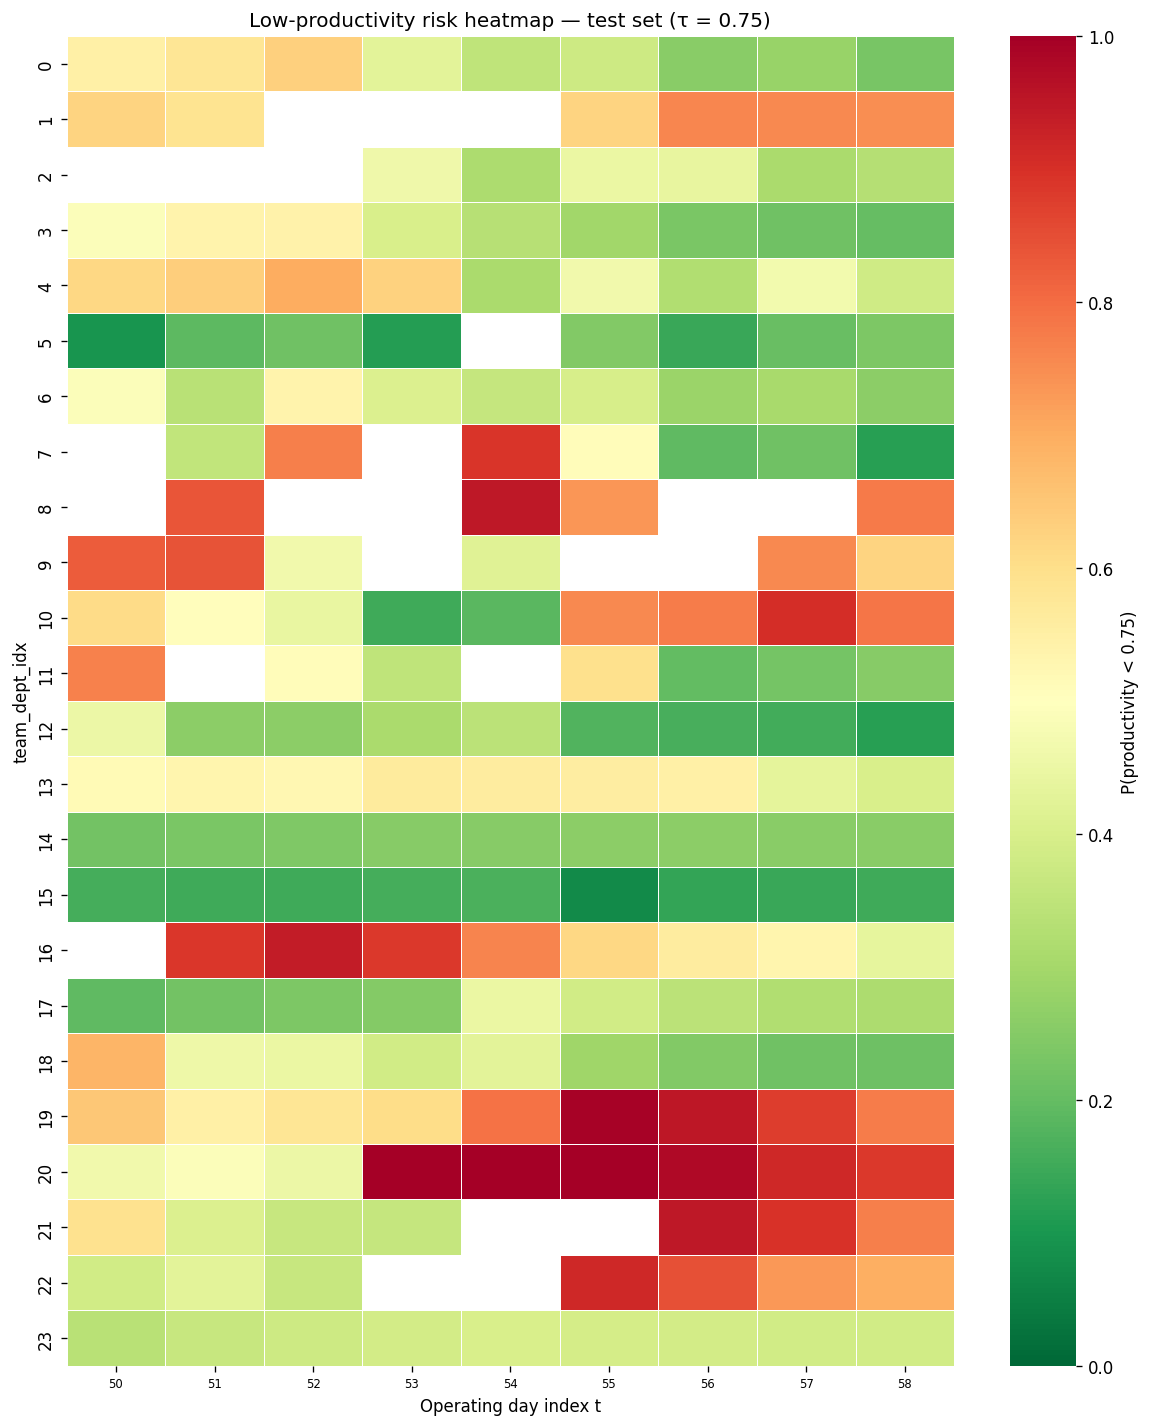

  ✓ Saved: 03_v7_risk_heatmap.png
  Alarms fired (p ≥ 0.392): 103 of 192 test rows
  Actual low days in test: 76 of 192 rows


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# §11C.1  P(y < τ) heatmap — team_dept_idx × operating day (test set)
import seaborn as sns

test_fc = df_forecasts[df_forecasts["split_code"] == 2].copy()
if len(test_fc) > 0:
    pivot = test_fc.pivot_table(index=GROUP_COL, columns="t", values="p_low", aggfunc="mean")
    fig, ax = plt.subplots(figsize=(max(10, len(pivot.columns)//2), max(5, len(pivot)//2)))
    sns.heatmap(
        pivot, ax=ax, cmap="RdYlGn_r", vmin=0, vmax=1,
        linewidths=0.3, linecolor="white",
        cbar_kws={"label": f"P(productivity < {TAU_PROD})"}
    )
    ax.set_title(f"Low-productivity risk heatmap — test set (τ = {TAU_PROD})")
    ax.set_xlabel("Operating day index t")
    ax.set_ylabel("team_dept_idx")
    ax.tick_params(axis="x", labelsize=7)
    plt.tight_layout()
    plt.savefig(OUT_DIR / "03_v7_risk_heatmap.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("  ✓ Saved: 03_v7_risk_heatmap.png")
    n_alarms = (test_fc["p_low"] >= P_STAR).sum()
    n_actual_low = (test_fc["actual_y"] < TAU_PROD).sum()
    print(f"  Alarms fired (p ≥ {P_STAR:.3f}): {n_alarms} of {len(test_fc)} test rows")
    print(f"  Actual low days in test: {n_actual_low} of {len(test_fc)} rows")
else:
    print("No test rows — heatmap skipped.")


## §11D · Multi-step Monte Carlo forecast

Monte Carlo propagation of the local-level DLM uncertainty over the test horizon for one group.
State uncertainty grows as `h·Q + R` per step; back-transformed to the original productivity scale.


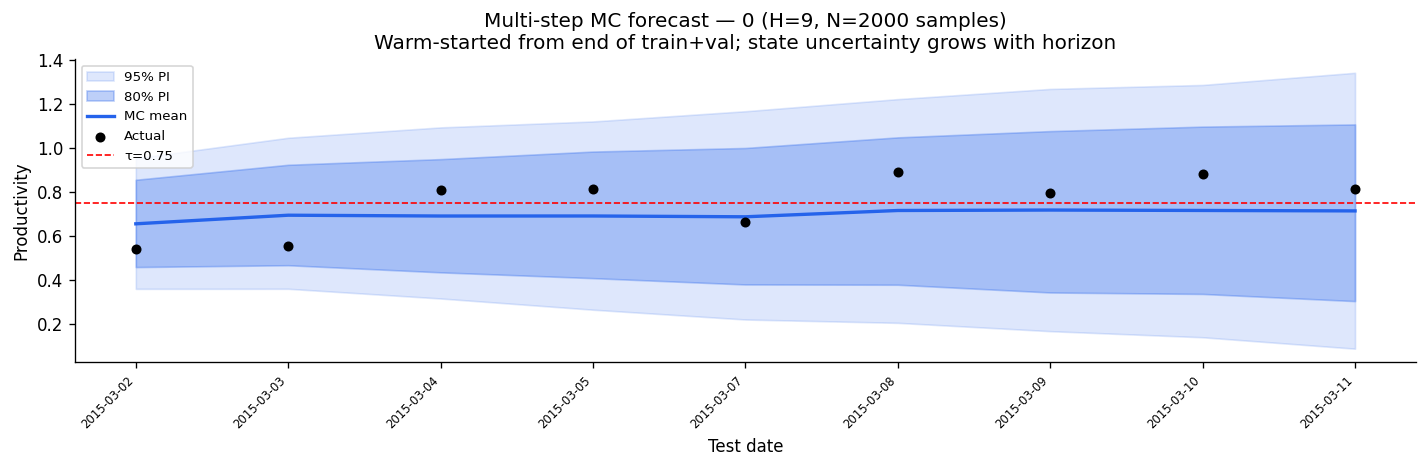

  ✓ Saved: 03_v7_multistep_mc.png


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# §11D.1  Multi-step MC forecast — first group, test horizon (up to 20 steps)
GROUPS_SORTED = sorted(df[GROUP_COL].unique())
MS_GROUP = GROUPS_SORTED[0]

df_g     = df[df[GROUP_COL] == MS_GROUP].sort_values("t").reset_index(drop=True)
test_g   = df_g[df_g["split_code"] == 2].reset_index(drop=True)
H        = min(20, len(test_g))

if H > 0:
    # Retrieve shrunk Q, R from the selected model
    ms_params = model_result["params"][MS_GROUP]
    Q_ms = ms_params["q"]
    R_ms = ms_params["r"]

    # State at the end of the training set (before val/test)
    # Rerun filter through train+val to get state at start of test
    train_val_g = df_g[df_g["split_code"].isin([0, 1])].reset_index(drop=True)
    offsets_g   = model_result["offsets"][df[GROUP_COL].eq(MS_GROUP).values]
    offsets_ms_trainval = offsets_g[df_g["split_code"].isin([0, 1]).values]
    y_trainval  = train_val_g["actual_productivity"].to_numpy(float)
    t_trainval  = train_val_g["t"].to_numpy(int)

    fr_ms = LocalLevelDLM.filter(
        y=y_trainval,
        offset=offsets_ms_trainval,
        t_index=t_trainval,
        q=Q_ms, r=R_ms,
        m0=float(y_trainval.mean() - offsets_ms_trainval.mean()),
        p0=0.02,
        robust_clip=ROBUST_CLIP,
    )
    m_start = float(fr_ms["m_filt"][-1])
    p_start = float(fr_ms["p_filt"][-1])

    # Test offsets
    offsets_ms_test = offsets_g[df_g["split_code"].eq(2).values][:H]
    t_test_g        = test_g["t"].to_numpy(int)[:H]

    # Monte Carlo propagation
    N_SAMPLES = 2000
    y_samples = np.zeros((N_SAMPLES, H))
    np.random.seed(42)
    for s in range(N_SAMPLES):
        m_s = np.random.normal(m_start, np.sqrt(p_start))
        p_s = p_start
        for h in range(H):
            dt_h = 1 if h == 0 else max(1, int(t_test_g[h] - t_test_g[h-1]))
            m_s  = m_s + np.random.normal(0, np.sqrt(dt_h * Q_ms))
            p_s  = p_s + dt_h * Q_ms
            eps  = np.random.normal(0, np.sqrt(R_ms))
            y_samples[s, h] = offsets_ms_test[h] + m_s + eps

    y_mean  = y_samples.mean(0)
    y_lo80  = np.percentile(y_samples, 10, 0)
    y_hi80  = np.percentile(y_samples, 90, 0)
    y_lo95  = np.percentile(y_samples,  2.5, 0)
    y_hi95  = np.percentile(y_samples, 97.5, 0)

    dates_test = test_g["date"].values[:H]
    actual_test = test_g["actual_productivity"].values[:H]

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.fill_between(range(H), y_lo95, y_hi95, alpha=0.15, color="#2563EB", label="95% PI")
    ax.fill_between(range(H), y_lo80, y_hi80, alpha=0.30, color="#2563EB", label="80% PI")
    ax.plot(range(H), y_mean, color="#2563EB", lw=2, label="MC mean")
    ax.scatter(range(H), actual_test, s=25, color="black", zorder=5, label="Actual")
    ax.axhline(TAU_PROD, color="red", ls="--", lw=1, label=f"τ={TAU_PROD}")
    ax.set_xticks(range(H))
    ax.set_xticklabels([str(d)[:10] for d in dates_test], rotation=45, ha="right", fontsize=7)
    ax.set_xlabel("Test date"); ax.set_ylabel("Productivity")
    ax.set_title(f"Multi-step MC forecast — {MS_GROUP} (H={H}, N={N_SAMPLES} samples)\n"
                 f"Warm-started from end of train+val; state uncertainty grows with horizon")
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(OUT_DIR / "03_v7_multistep_mc.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  ✓ Saved: 03_v7_multistep_mc.png")
else:
    print(f"No test rows for group {MS_GROUP} — skipping.")


## §12 · Comparison with Imran et al. (2021)

This table is **descriptive only** — the tasks differ substantially.

| Dimension | Imran et al. 2021 | This notebook (v7.2) |
|---|---|---|
| Split | Random 70/30 | Chronological train/val/test |
| Task | Static classification (3-class / 2-class) | Rolling one-step-ahead regression + alarm |
| Features | All available | Forecast-safe subset (planning-stage) |
| Primary metric | Accuracy (3-class), AUC (2-class) | RMSE vs baselines, AUC (alarm) |
| Class boundary | Paper-specific | y < 0.75 (τ) |
| Oversampling | SMOTE for 2-class | None |

The DLM adds temporal forecasting, drift tracking, and calibrated uncertainty — capabilities outside the paper's scope.


In [ ]:
# §12.1  Comparison table
def fmt(v, d=4):
    if v is None: return "N/A"
    if isinstance(v, float) and np.isnan(v): return "N/A"
    return f"{v:.{d}f}"

tm = metrics_table[metrics_table["split"]=="test"].iloc[0]
vm = metrics_table[metrics_table["split"]=="validation"].iloc[0]

comparison_rows = [
    {
        "Model":          "Paper Tree Ensemble (3-class)",
        "Split":          "test (random 70/30)",
        "Primary metric": "Accuracy = 83.89%",
        "AUC":            "N/A (3-class)",
        "RMSE":           "N/A",
        "Note":           "Imran et al. 2021; random split; accuracy is primary metric"
    },
    {
        "Model":          "Paper GBT + SMOTE (2-class)",
        "Split":          "test (random 70/30)",
        "Primary metric": "Accuracy = 86.39%",
        "AUC":            "reported separately",
        "RMSE":           "N/A",
        "Note":           "SMOTE oversampling; different class boundary; task differs"
    },
    {
        "Model":          "DLM v7.2 — static Ridge only",
        "Split":          "test (chronological)",
        "Primary metric": f"RMSE = {fmt(tm['StaticRidge_RMSE'])}",
        "AUC":            "N/A",
        "RMSE":           fmt(tm["StaticRidge_RMSE"]),
        "Note":           "Baseline — planning features only; no temporal dynamics"
    },
    {
        "Model":          "DLM v7.2 — final forecast",
        "Split":          "validation (chronological)",
        "Primary metric": f"RMSE = {fmt(vm['Final_RMSE'])}",
        "AUC":            fmt(vm["AUC"]),
        "RMSE":           fmt(vm["Final_RMSE"]),
        "Note":           f"Skill vs group mean = {fmt(vm['Skill_vs_GroupMean_pct'],1)}%"
    },
    {
        "Model":          "DLM v7.2 — final forecast",
        "Split":          "test (chronological)",
        "Primary metric": f"RMSE = {fmt(tm['Final_RMSE'])}",
        "AUC":            fmt(tm["AUC"]),
        "RMSE":           fmt(tm["Final_RMSE"]),
        "Note":           f"Skill vs group mean = {fmt(tm['Skill_vs_GroupMean_pct'],1)}%"
    },
]
comparison_df = pd.DataFrame(comparison_rows)
pd.set_option("display.max_colwidth", 60)
pd.set_option("display.width", 320)
print(comparison_df.to_string(index=False))
print()
print("Direct metric comparison is invalid — the tasks, splits, feature sets and")
print("class definitions differ. The DLM provides temporal forecasting and calibrated")
print("uncertainty that are outside the paper's scope.")


                        Model                      Split    Primary metric                 AUC   RMSE                                                        Note
Paper Tree Ensemble (3-class)        test (random 70/30) Accuracy = 83.89%       N/A (3-class)    N/A Imran et al. 2021; random split; accuracy is primary metric
  Paper GBT + SMOTE (2-class)        test (random 70/30) Accuracy = 86.39% reported separately    N/A  SMOTE oversampling; different class boundary; task differs
 DLM v7.2 — static Ridge only       test (chronological)     RMSE = 0.1330                 N/A 0.1330     Baseline — planning features only; no temporal dynamics
    DLM v7.2 — final forecast validation (chronological)     RMSE = 0.1519              0.7900 0.1519                                 Skill vs group mean = 25.6%
    DLM v7.2 — final forecast       test (chronological)     RMSE = 0.1316              0.8717 0.1316                                 Skill vs group mean = 18.8%

Direct metric comparison is

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## §12 · Save outputs

In [ ]:
# §12.1 Save tables and model artifact
save_tables = {
    "03_v7_1_forecasts.csv": df_forecasts,
    "03_v7_1_metrics.csv": metrics_table,
    "03_v7_1_acceptance_checks.csv": checks,
    "03_v7_1_alpha_tuning.csv": alpha_tuning,
    "03_v7_1_blend_tuning.csv": blend_tuning,
    "03_v7_1_group_parameters.csv": params_table,
}
for filename, table in save_tables.items():
    path = MODEL_DIR / filename
    table.to_csv(path, index=False)
    print("✓", path)

artifact = {
    "version": "7.1",
    "group_col": GROUP_COL,
    "forecast_features": FORECAST_FEATURES,
    "selected_alpha": SELECTED_ALPHA,
    "blend_weight_dlm": BLEND_WEIGHT_DLM,
    "pool_strength": POOL_STRENGTH,
    "robust_clip": ROBUST_CLIP,
    "tau_productivity": TAU_PROD,
    "interval_k80": K80,
    "interval_k95": K95,
    "alarm_threshold": P_STAR,
    "ridge": model_result["ridge"],
    "scaler": scaler,
    "params": model_result["params"],
    "metrics": metrics_table,
    "acceptance_checks": checks,
    "probability_calibrator": probability_calibrator,
}

with open(MODEL_DIR / "03_v7_1_model.pkl", "wb") as f:
    pickle.dump(artifact, f)

summary = {
    "version": "7.1",
    "selected_alpha": SELECTED_ALPHA,
    "blend_weight_dlm": BLEND_WEIGHT_DLM,
    "pool_strength": POOL_STRENGTH,
    "robust_clip": ROBUST_CLIP,
    "tau_productivity": TAU_PROD,
    "interval_k80": K80,
    "interval_k95": K95,
    "alarm_threshold": P_STAR,
    "metrics": metrics_table.to_dict(orient="records"),
    "acceptance_checks": checks.to_dict(orient="records"),
}
with open(MODEL_DIR / "03_v7_1_summary.json", "w") as f:
    json.dump(summary, f, indent=2, default=str)

print("✓ Saved model pickle and JSON summary")
# v7.2 additions
if CAN_RUN_UPLIFT:
    df_uplift.to_csv(MODEL_DIR / "03_v7_2_incentive_uplift.csv", index=False)
    print("✓ 03_v7_2_incentive_uplift.csv")
    df_wip_uplift.to_csv(MODEL_DIR / "03_v7_2_wip_uplift.csv", index=False)
    print("✓ 03_v7_2_wip_uplift.csv")
comparison_df.to_csv(MODEL_DIR / "03_v7_2_paper_comparison.csv", index=False)
print("✓ 03_v7_2_paper_comparison.csv")


✓ /content/ProdFusion/models/03_v7_1_forecasts.csv
✓ /content/ProdFusion/models/03_v7_1_metrics.csv
✓ /content/ProdFusion/models/03_v7_1_acceptance_checks.csv
✓ /content/ProdFusion/models/03_v7_1_alpha_tuning.csv
✓ /content/ProdFusion/models/03_v7_1_blend_tuning.csv
✓ /content/ProdFusion/models/03_v7_1_group_parameters.csv
✓ Saved model pickle and JSON summary
✓ 03_v7_2_incentive_uplift.csv
✓ 03_v7_2_wip_uplift.csv
✓ 03_v7_2_paper_comparison.csv


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# §12.2 Final report
print("\n" + "═" * 78)
print(" CORRECTED DLM v7.2 COMPLETE ".center(78, "═"))
print("═" * 78)
print(f"Response scale              : original productivity; no clipping or target scaling")
print(f"Dynamic states per group    : 1 local level")
print(f"Groups                      : {df[GROUP_COL].nunique()}")
print(f"Selected Ridge alpha        : {SELECTED_ALPHA:g} (validation only)")
print(f"Kalman weight in final mean : {BLEND_WEIGHT_DLM:.2f} (validation only)")
print(f"Low-day definition          : actual_productivity < {TAU_PROD}")
print(f"Test final RMSE             : {test_metrics['Final_RMSE']:.5f}")
print(f"Test raw DLM RMSE           : {test_metrics['RawDLM_RMSE']:.5f}")
print(f"Test static Ridge RMSE      : {test_metrics['StaticRidge_RMSE']:.5f}")
print(f"Test group-mean RMSE        : {test_metrics['GroupMean_RMSE']:.5f}")
print(f"Test skill vs group mean    : {test_metrics['Skill_vs_GroupMean_pct']:.2f}%")
print(f"Test skill vs static Ridge  : {test_metrics['Skill_vs_StaticRidge_pct']:.2f}%")
print(f"Test 80% / 95% coverage     : {test_metrics['Coverage80']:.3f} / {test_metrics['Coverage95']:.3f}")
print(f"Test AUC / AP / Brier       : {test_metrics['AUC']:.3f} / {test_metrics['AP']:.3f} / {test_metrics['Brier']:.3f}")
print(f"Overall status              : {'PASS' if checks['passed'].all() else 'REVIEW REQUIRED'}")
print("═" * 78)
print()
print("Additional deliverables (v7.2):")
print(f"  Incentive uplift curves  : {'✓ saved' if CAN_RUN_UPLIFT else '⚠ skipped (missing lever features)'}")
print(f"  WIP what-if curves       : {'✓ saved' if CAN_RUN_UPLIFT else '⚠ skipped'}")
print(f"  Budget allocator         : {'✓ saved' if CAN_RUN_UPLIFT else '⚠ skipped'}")
print(  "  Risk heatmap             : ✓ saved")
print(  "  Multi-step MC forecast   : ✓ saved")
print(  "  Paper comparison table   : ✓ saved")
print("═" * 78)



══════════════════════════════════════════════════════════════════════════════
════════════════════════ CORRECTED DLM v7.2 COMPLETE ═════════════════════════
══════════════════════════════════════════════════════════════════════════════
Response scale              : original productivity; no clipping or target scaling
Dynamic states per group    : 1 local level
Groups                      : 24
Selected Ridge alpha        : 0.01 (validation only)
Kalman weight in final mean : 0.65 (validation only)
Low-day definition          : actual_productivity < 0.75
Test final RMSE             : 0.13161
Test raw DLM RMSE           : 0.14537
Test static Ridge RMSE      : 0.13299
Test group-mean RMSE        : 0.16199
Test skill vs group mean    : 18.75%
Test skill vs static Ridge  : 1.04%
Test 80% / 95% coverage     : 0.885 / 0.979
Test AUC / AP / Brier       : 0.872 / 0.815 / 0.152
Overall status              : PASS
══════════════════════════════════════════════════════════════════════════════

Add